In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
from scipy.stats import chi2_contingency, f_oneway, jarque_bera, probplot
import plotly.express as px

In [2]:
from google.colab import files
uploaded = files.upload()

In [4]:
from google.colab import files
uploaded = files.upload()

Saving swiggy_cleaned.csv to swiggy_cleaned.csv


In [5]:
df_final = pd.read_csv('swiggy_cleaned.csv')

In [6]:
df_final.sample(5)

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,time_taken,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance
23313,SURRES12DEL03,35.0,4.8,21.183434,72.814492,21.273434,72.904492,2022-03-04,sunny,jam,...,16,SUR,4,3,friday,0,10.0,19.0,evening,13.681057
24611,JAPRES05DEL02,23.0,4.7,26.905287,75.794592,26.985287,75.874592,2022-03-06,windy,low,...,13,JAP,6,3,sunday,1,5.0,22.0,night,11.916990
9708,RANCHIRES13DEL02,37.0,4.7,23.374989,85.335486,23.394989,85.355486,2022-03-19,fog,low,...,16,RANCHI,19,3,saturday,1,5.0,10.0,morning,3.018662
31937,PUNERES04DEL02,29.0,4.8,18.514210,73.838429,18.534210,73.858429,2022-03-24,sunny,high,...,13,PUNE,24,3,thursday,0,10.0,11.0,morning,3.064677
7159,COIMBRES13DEL03,26.0,5.0,11.003669,76.976494,11.033669,77.006494,2022-04-03,cloudy,jam,...,20,COIMB,3,4,sunday,1,10.0,19.0,evening,4.674319


In [7]:
df_final.isna().sum()

,0
rider_id,0
age,1854
ratings,1908
restaurant_latitude,3630
restaurant_longitude,3630
delivery_latitude,3630
delivery_longitude,3630
order_date,0
weather,525
traffic,510


In [8]:
num_cols = df_final.select_dtypes(include=['number']).columns
print(num_cols)

Index(['age', 'ratings', 'restaurant_latitude', 'restaurant_longitude',
       'delivery_latitude', 'delivery_longitude', 'vehicle_condition',
       'multiple_deliveries', 'time_taken', 'order_day', 'order_month',
       'is_weekend', 'pickup_time_minutes', 'order_time_hour', 'distance'],
      dtype='object')


In [9]:
columns_in_df=df_final.columns.tolist()
columns_in_df

['rider_id',
 'age',
 'ratings',
 'restaurant_latitude',
 'restaurant_longitude',
 'delivery_latitude',
 'delivery_longitude',
 'order_date',
 'weather',
 'traffic',
 'vehicle_condition',
 'type_of_order',
 'type_of_vehicle',
 'multiple_deliveries',
 'festival',
 'city_type',
 'time_taken',
 'city_name',
 'order_day',
 'order_month',
 'order_day_of_week',
 'is_weekend',
 'pickup_time_minutes',
 'order_time_hour',
 'order_time_of_day',
 'distance']

In [14]:
cat_cols = [col for col in df_final.columns.tolist() if col not in num_cols]
cat_cols

['rider_id',
 'order_date',
 'weather',
 'traffic',
 'type_of_order',
 'type_of_vehicle',
 'festival',
 'city_type',
 'city_name',
 'order_day_of_week',
 'order_time_of_day']

In [12]:
df_final[num_cols].describe()

,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,vehicle_condition,multiple_deliveries,time_taken,order_day,order_month,is_weekend,pickup_time_minutes,order_time_hour,distance
count,43648.000000,43594.000000,41872.000000,41872.000000,41872.000000,41872.000000,45502.000000,44509.000000,45502.000000,45502.000000,45502.000000,45502.000000,43862.000000,43862.000000,41872.000000
mean,29.555008,4.635287,18.913696,76.921664,18.977356,76.985325,1.019406,0.744928,26.297591,13.811657,2.980726,0.274867,9.989399,17.423966,9.719296
std,5.761482,0.313827,5.467265,3.503107,5.469056,3.503260,0.835229,0.572488,9.386419,8.709540,0.546031,0.446452,4.087516,4.817856,5.602890
min,20.000000,2.500000,9.957144,72.768726,9.967144,72.778726,0.000000,0.000000,10.000000,1.000000,2.000000,0.000000,5.000000,0.000000,1.465067
25%,25.000000,4.500000,12.986047,73.897902,13.065996,73.940327,0.000000,0.000000,19.000000,6.000000,3.000000,0.000000,5.000000,15.000000,4.657655
50%,30.000000,4.700000,19.065838,76.618203,19.124049,76.662620,1.000000,1.000000,26.000000,13.000000,3.000000,0.000000,10.000000,19.000000,9.193014
75%,35.000000,4.900000,22.751234,78.368855,22.820040,78.405467,2.000000,1.000000,32.000000,20.000000,3.000000,1.000000,15.000000,21.000000,13.680920
max,39.000000,5.000000,30.914057,88.433452,31.054057,88.563452,3.000000,3.000000,54.000000,31.000000,4.000000,1.000000,15.000000,23.000000,20.969489


In [15]:
# statistical summary of categorical columns

(
    df_final
    .assign(**{
        col: df_final[col].astype("object")
        for col in cat_cols
    })
    .describe(include="object")
    .T
)

,count,unique,top,freq
rider_id,45502,1320,PUNERES01DEL01,67
order_date,45502,44,2022-03-15,1190
weather,44977,6,fog,7654
traffic,44992,4,low,15477
type_of_order,45502,4,snack,11512
type_of_vehicle,45502,4,motorcycle,26427
festival,45274,2,no,44380
city_type,44304,3,metropolitian,34029
city_name,45502,22,JAP,3439
order_day_of_week,45502,7,wednesday,7077


## Missing Value Analysis

<Axes: >

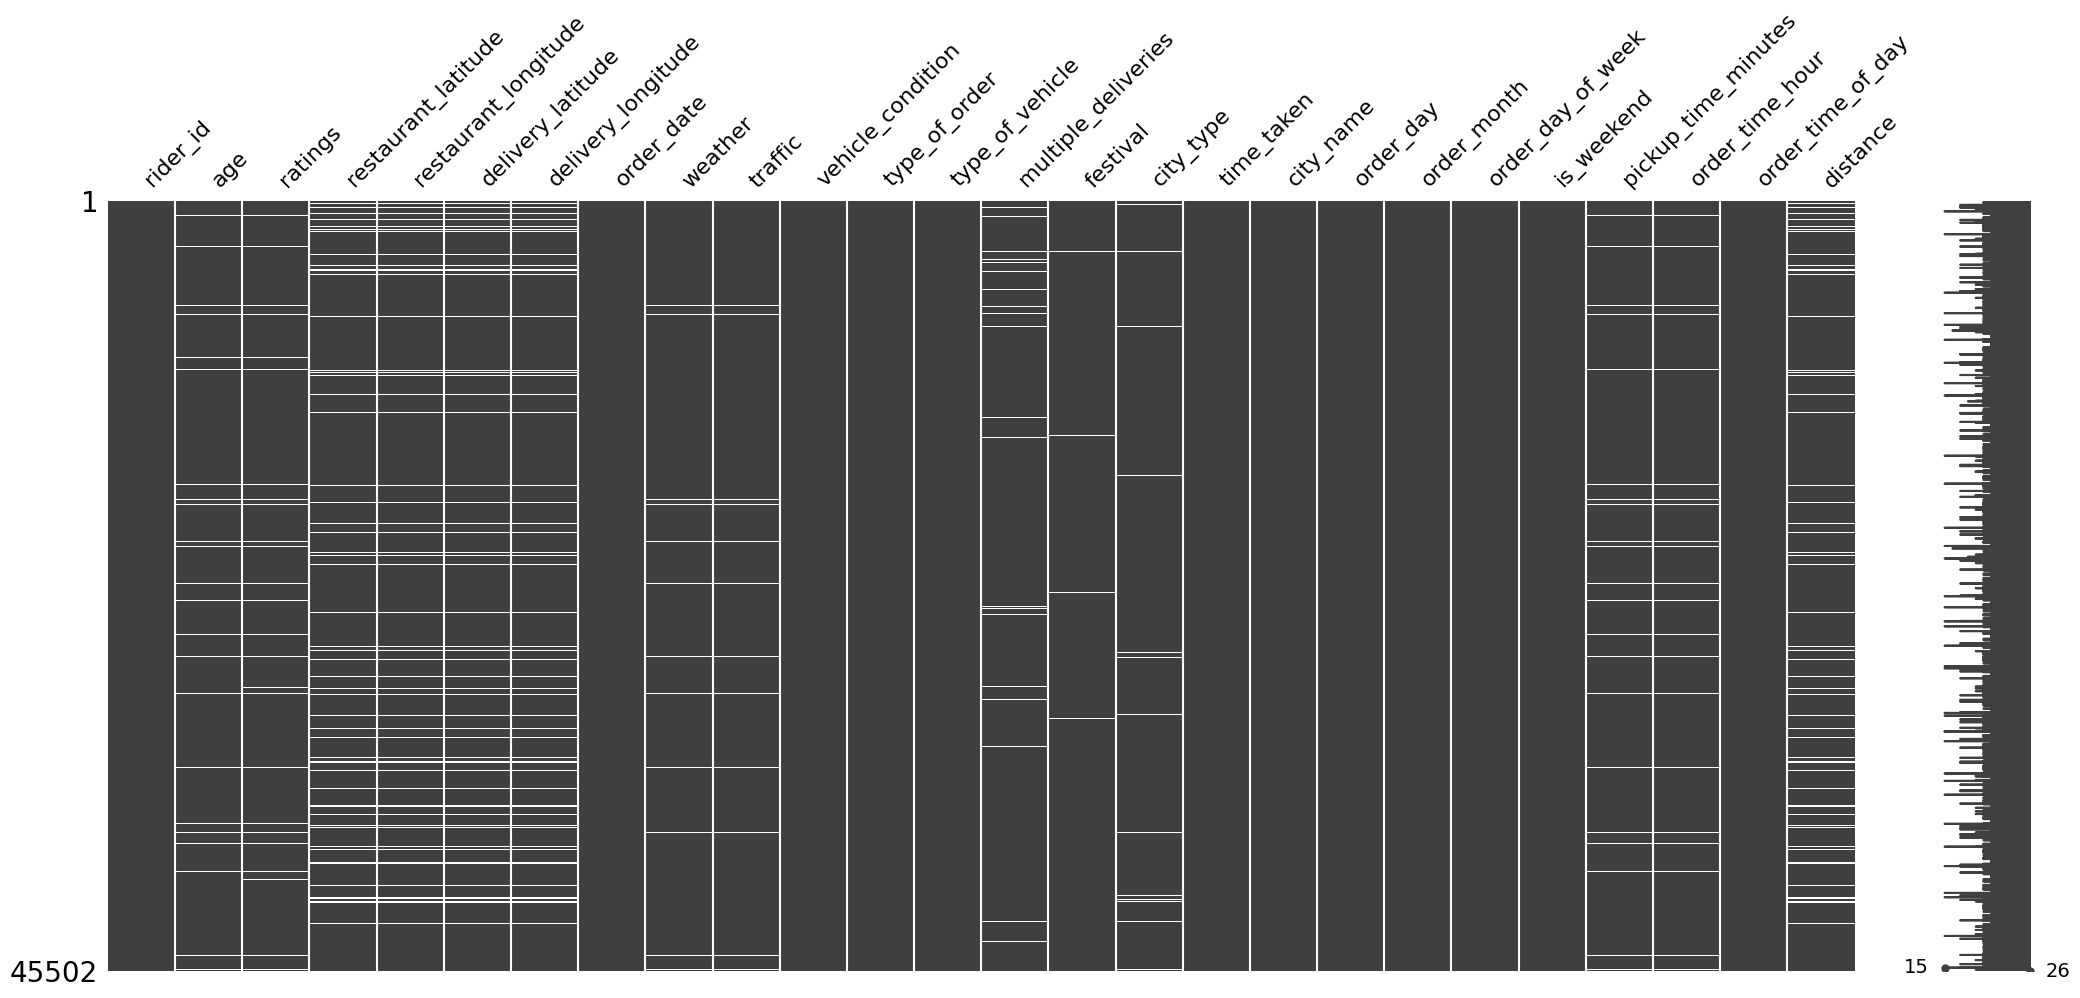

In [16]:
import missingno as msno
msno.matrix(df_final)

In [17]:
df_final.head(5)

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,time_taken,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,sunny,high,...,24,INDO,19,3,saturday,1,15.0,11.0,morning,3.025149
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,stormy,jam,...,33,BANG,25,3,friday,0,5.0,19.0,evening,20.183530
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,sandstorms,low,...,26,BANG,19,3,saturday,1,15.0,8.0,morning,1.552758
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,sunny,medium,...,21,COIMB,5,4,tuesday,0,10.0,18.0,evening,7.790401
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,cloudy,high,...,30,CHEN,26,3,saturday,1,15.0,13.0,afternoon,6.210138


# Functions to perform analysis

In [55]:

def numerical_analysis(dataframe, column_name, cat_col=None, bins="auto"):
    # create the figure
    fig = plt.figure(figsize=(15,10))
    # generate the layout
    grid = GridSpec(nrows=2, ncols=2, figure=fig)
    # set subplots
    ax1 = fig.add_subplot(grid[0, 0])
    ax2 = fig.add_subplot(grid[0, 1])
    ax3 = fig.add_subplot(grid[1, :])
    # plot the kdeplot
    sns.kdeplot(data=dataframe, x=column_name,hue=cat_col, ax=ax1)
    # plot the boxplot
    sns.boxplot(data=dataframe, x=column_name,hue=cat_col, ax=ax2)
    # plot the histogram
    sns.histplot(data=dataframe, x=column_name,bins=bins,hue=cat_col,kde=True, ax=ax3)
    plt.tight_layout()
    plt.show()
def numerical_categorical_analysis(dataframe, cat_column_1, num_column):
    fig, (ax1, ax2) = plt.subplots(2, 2, figsize=(15,7.5))
    # plot the barplot
    sns.barplot(data=dataframe, x=cat_column_1, y=num_column, ax=ax1[0])
    # plot the boxplot
    sns.boxplot(data=dataframe, x=cat_column_1, y=num_column, ax=ax1[1])
    # plot violin plot
    sns.violinplot(data=dataframe, x=cat_column_1, y=num_column, ax=ax2[0])
    # plot strip plot
    sns.stripplot(data=dataframe, x=cat_column_1, y=num_column, ax=ax2[1])
    plt.tight_layout()
    plt.show()
def categorical_analysis(dataframe, column_name):
    # print the values counts of categories
    display(
        pd.DataFrame({
            "Count": (
                dataframe[column_name]
                .value_counts()),
            "Percentage": (
                dataframe[column_name]
                .value_counts(normalize=True)
                .mul(100)
                .round(2)
                .astype("str")
                .add("%")
                )
        })
    )
    print("*" * 50)
    # get unique categories
    unique_categories = dataframe[column_name].unique().tolist()
    number_of_categories = dataframe[column_name].nunique()
    print(f"The unique categories in {column_name} column are {unique_categories}")
    print("*" * 50)
    print(f"The number of categories in {column_name} column are {number_of_categories}")
    # plot countplot
    sns.countplot(data=dataframe, x=column_name)
    plt.xticks(rotation=45)
    plt.show()

def multivariate_analysis(dataframe, num_column, cat_column_1, cat_column_2):
    fig, (ax1, ax2) = plt.subplots(2, 2, figsize=(15,7.5))
    # plot the barplot
    sns.barplot(data=dataframe, x=cat_column_1,
                y=num_column,hue=cat_column_2, ax=ax1[0])
    # plot the boxplot
    sns.boxplot(data=dataframe, x=cat_column_1,
                y=num_column,hue=cat_column_2, gap=0.1, ax=ax1[1])
    # plot violin plot
    sns.violinplot(data=dataframe, x=cat_column_1, gap=0.1,
                   y=num_column,hue=cat_column_2, ax=ax2[0])
    # plot strip plot
    sns.stripplot(data=dataframe, x=cat_column_1,
                  y=num_column,hue=cat_column_2,dodge=True,ax=ax2[1])
    plt.tight_layout()
    plt.show()


In [19]:
num_cols

Index(['age', 'ratings', 'restaurant_latitude', 'restaurant_longitude',
       'delivery_latitude', 'delivery_longitude', 'vehicle_condition',
       'multiple_deliveries', 'time_taken', 'order_day', 'order_month',
       'is_weekend', 'pickup_time_minutes', 'order_time_hour', 'distance'],
      dtype='object')

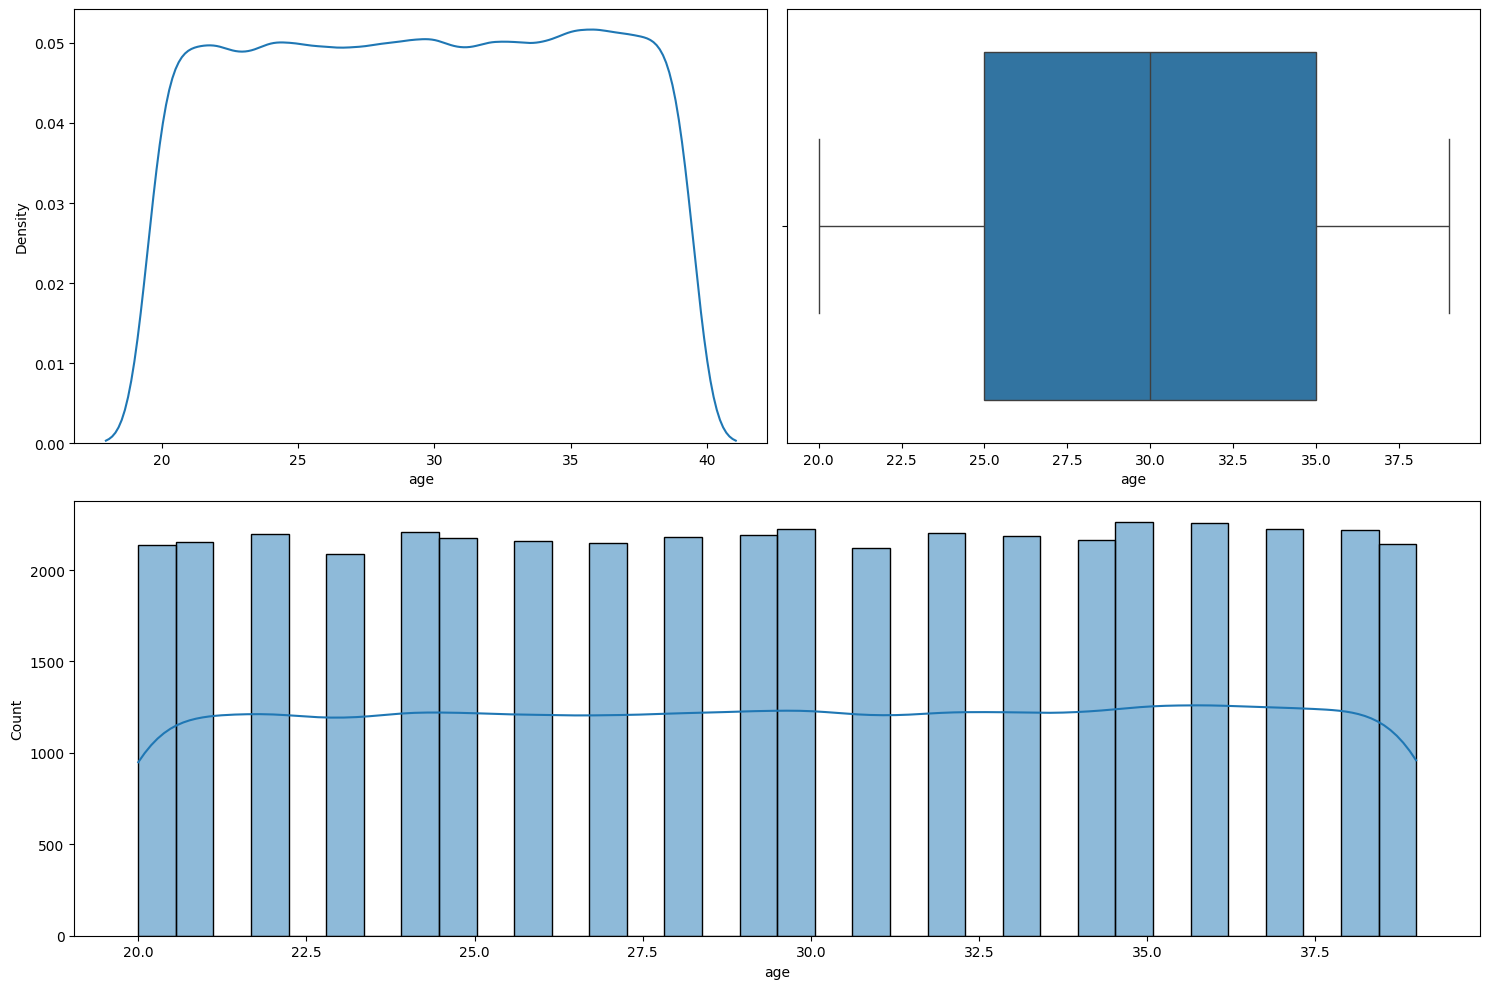

In [20]:
numerical_analysis(df_final,'age')

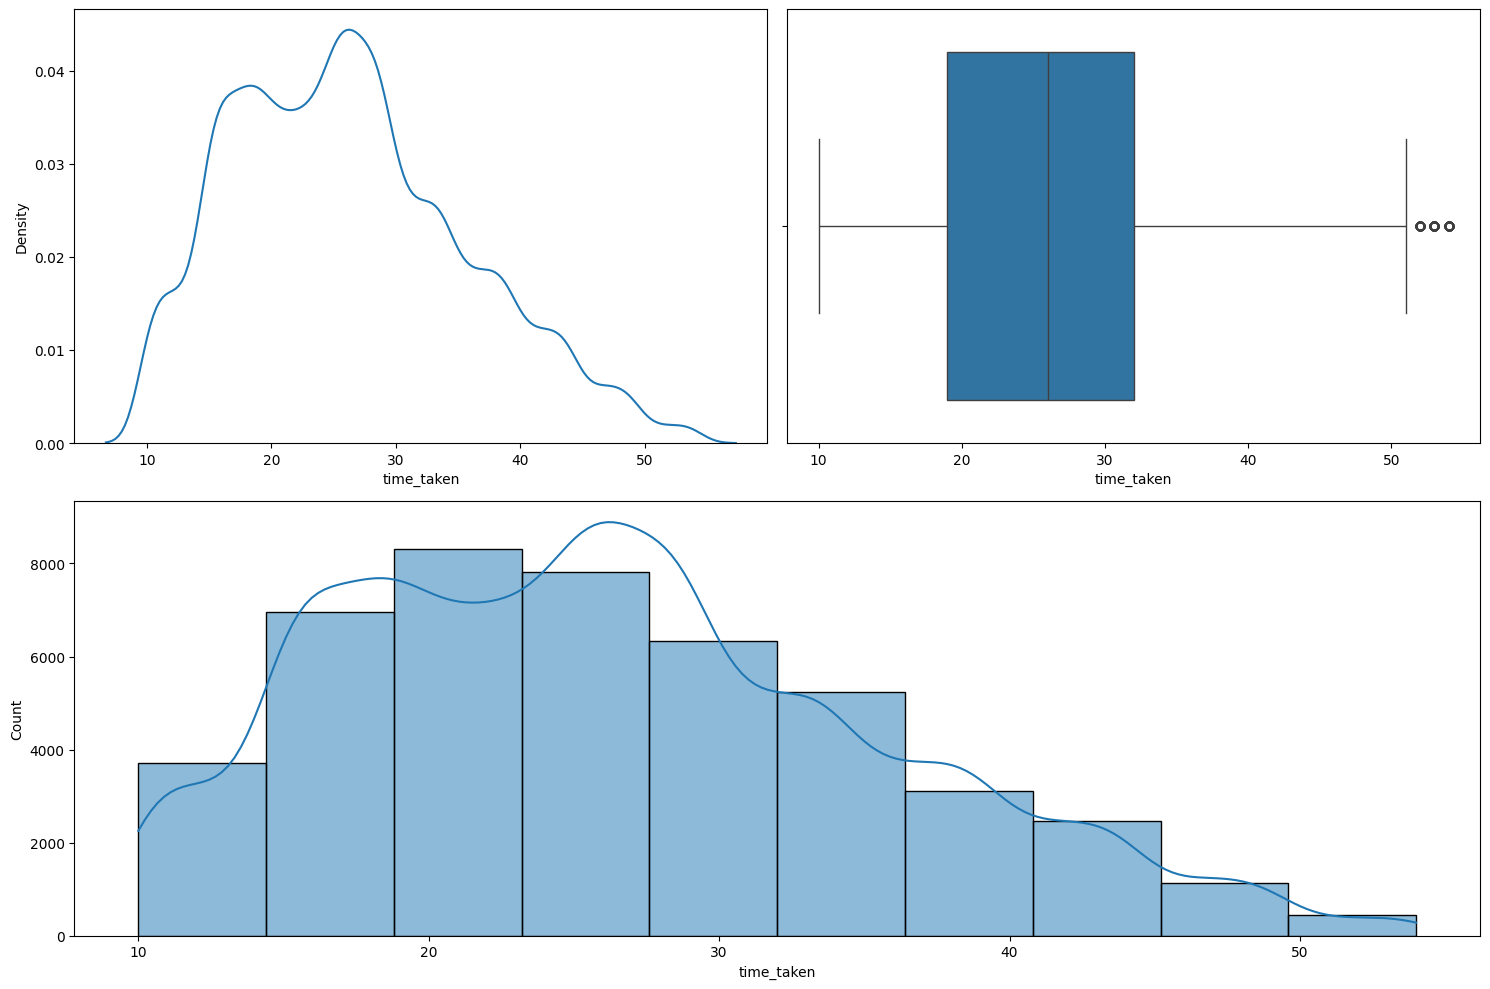

In [21]:
numerical_analysis(df_final, 'time_taken',bins=10)

**Observations**:

1. The target column is not fully continuous in nature.
2. The target column shows dual modality with two peaks- One peak around the 17-18 mark and other around 26-27 mark.
4. The target column has some extreme points which can be thought of as outliers but they are just extreme and rare, not outliers. 50 min time is possible for delivery in certain rare cases.

In [22]:
df_final.columns

Index(['rider_id', 'age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'order_date', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'time_taken', 'city_name', 'order_day', 'order_month',
       'order_day_of_week', 'is_weekend', 'pickup_time_minutes',
       'order_time_hour', 'order_time_of_day', 'distance'],
      dtype='object')

## Rider_ID

In [23]:
df_final['rider_id'].duplicated().sum()

np.int64(44182)

In [24]:
df_final.shape

(45502, 26)

In [25]:
rider_id_group = df_final[["rider_id","age","ratings"]].groupby('rider_id')
rider_id_group.head(5).sort_values('rider_id')

,rider_id,age,ratings
92,AGRRES010DEL01,34.0,4.7
7738,AGRRES010DEL01,21.0,4.7
4554,AGRRES010DEL01,38.0,4.7
12416,AGRRES010DEL01,34.0,4.5
13223,AGRRES010DEL01,39.0,4.4
...,...,...,...
861,VADRES20DEL03,35.0,4.8
9792,VADRES20DEL03,30.0,4.6
9753,VADRES20DEL03,38.0,4.8
5094,VADRES20DEL03,35.0,4.9


In [26]:
df_final[["rider_id","age","ratings"]].dropna().duplicated(keep='first').sum()

np.int64(5391)

In [27]:
df_final[["rider_id","age","ratings"]].dropna().duplicated(keep=False).sum()

np.int64(10155)

In [28]:
# filter the duplicates

(
    df_final
    .loc[(df_final[["rider_id","age","ratings"]].duplicated(keep=False)),["rider_id","age","ratings"]]
    .dropna()
    .sort_values(["rider_id"])
)

,rider_id,age,ratings
18533,AGRRES03DEL02,24.0,4.9
40285,AGRRES03DEL02,24.0,4.9
28473,AGRRES03DEL03,30.0,4.7
26275,AGRRES03DEL03,30.0,4.7
36131,AGRRES06DEL02,36.0,4.9
...,...,...,...
12742,VADRES20DEL02,28.0,4.5
5094,VADRES20DEL03,35.0,4.9
17963,VADRES20DEL03,35.0,4.9
21957,VADRES20DEL03,37.0,4.9


**Not Useful for our analysis**

**AGE**

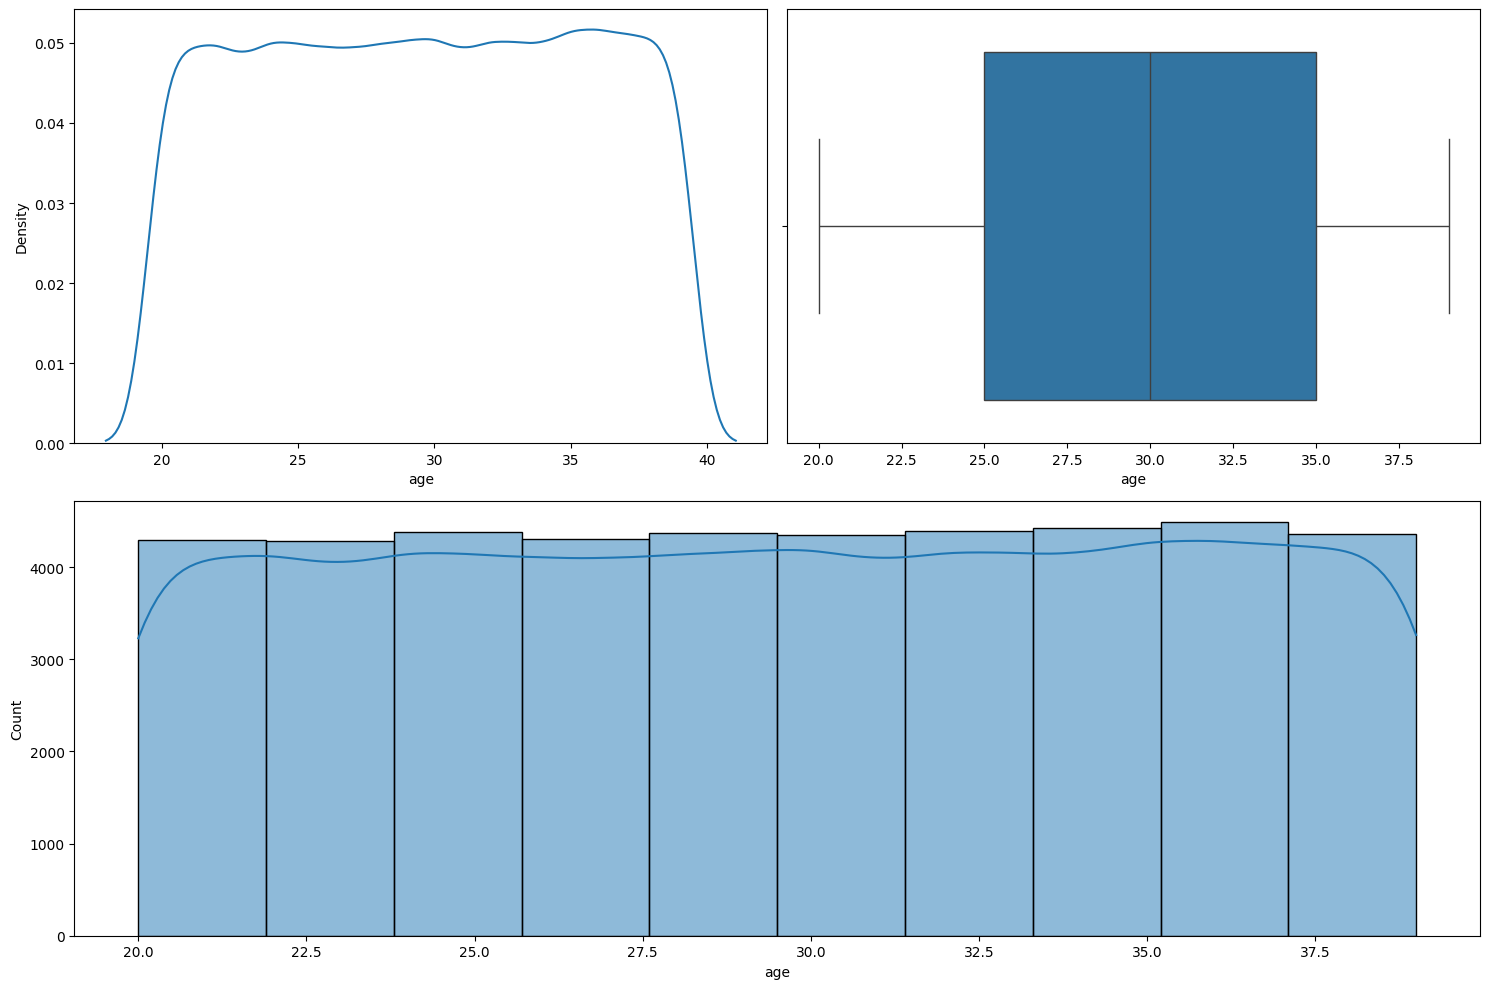

In [29]:
numerical_analysis(df_final, 'age',bins=10)

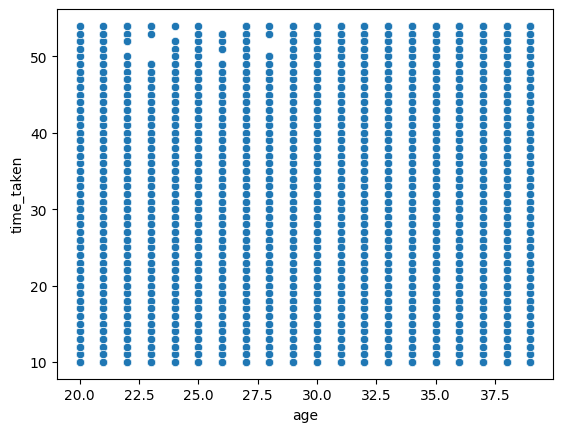

In [30]:
# relationship between target and age

sns.scatterplot(data=df_final, x='age', y='time_taken')
plt.show()

**Age of the rider does not show any impact on timetaken to deliver**

**RATINGS**

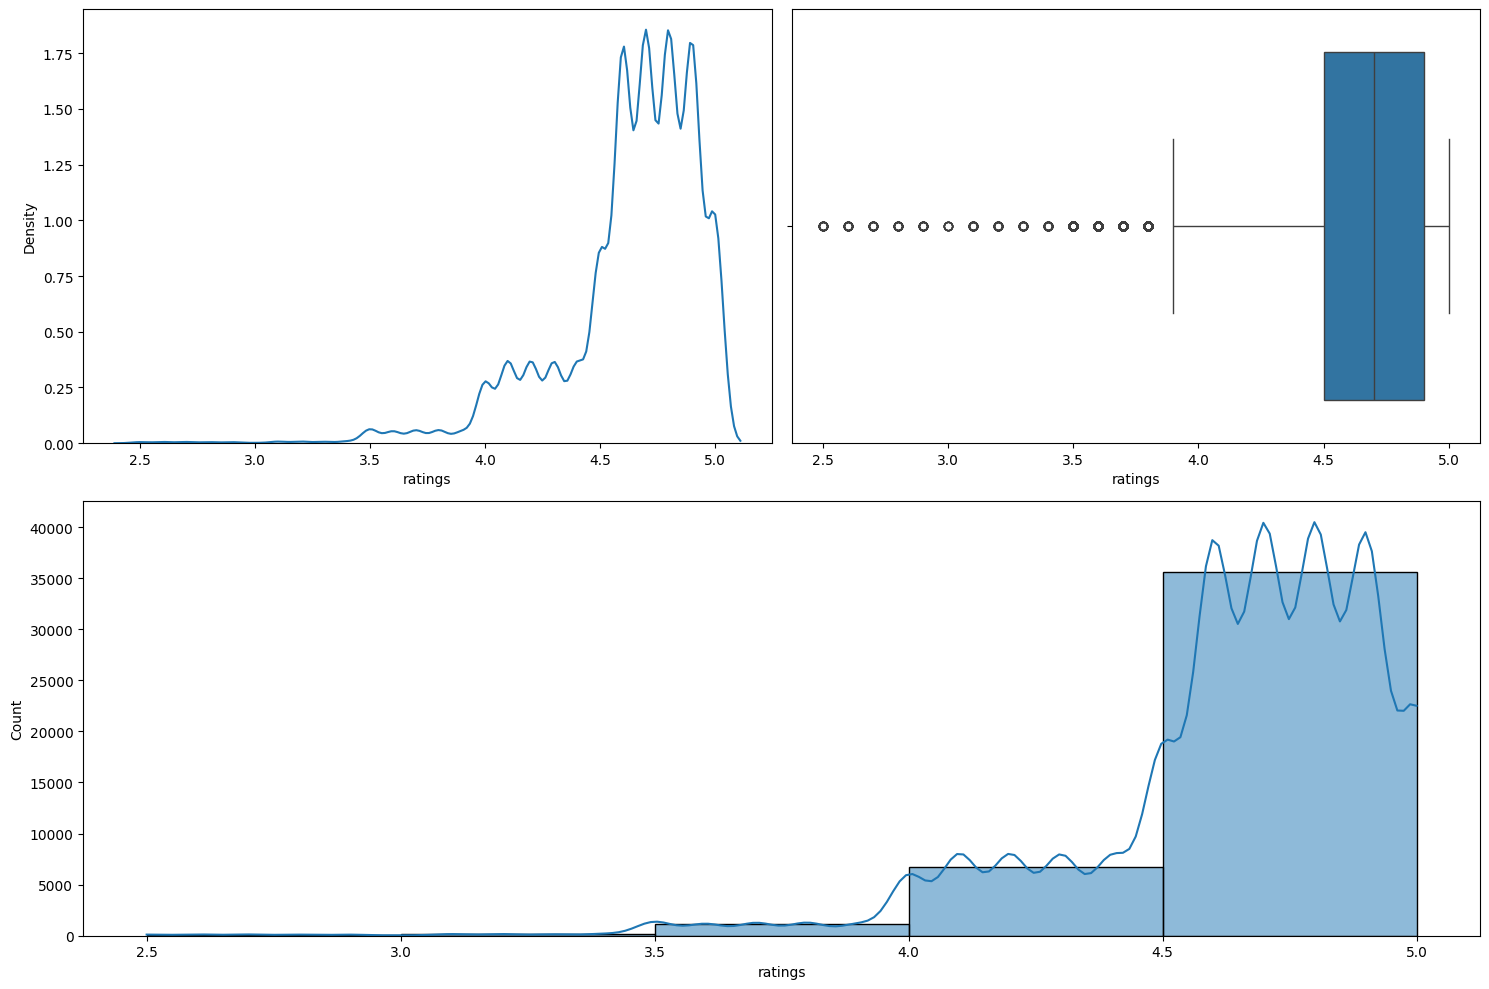

In [31]:
numerical_analysis(df_final, 'ratings',bins=5)

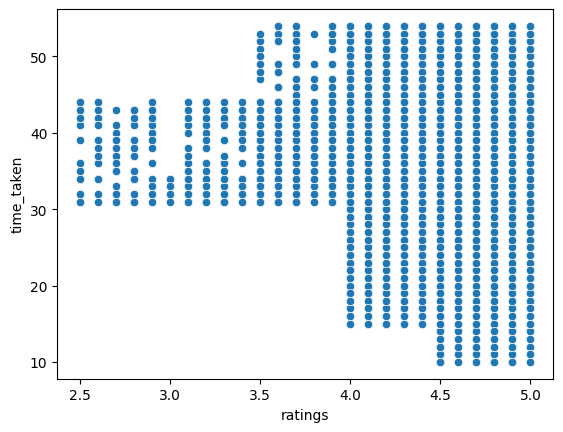

In [32]:
sns.scatterplot(data=df_final, x='ratings', y='time_taken')
plt.show()

**It seems like riders with more ratings get more orders**

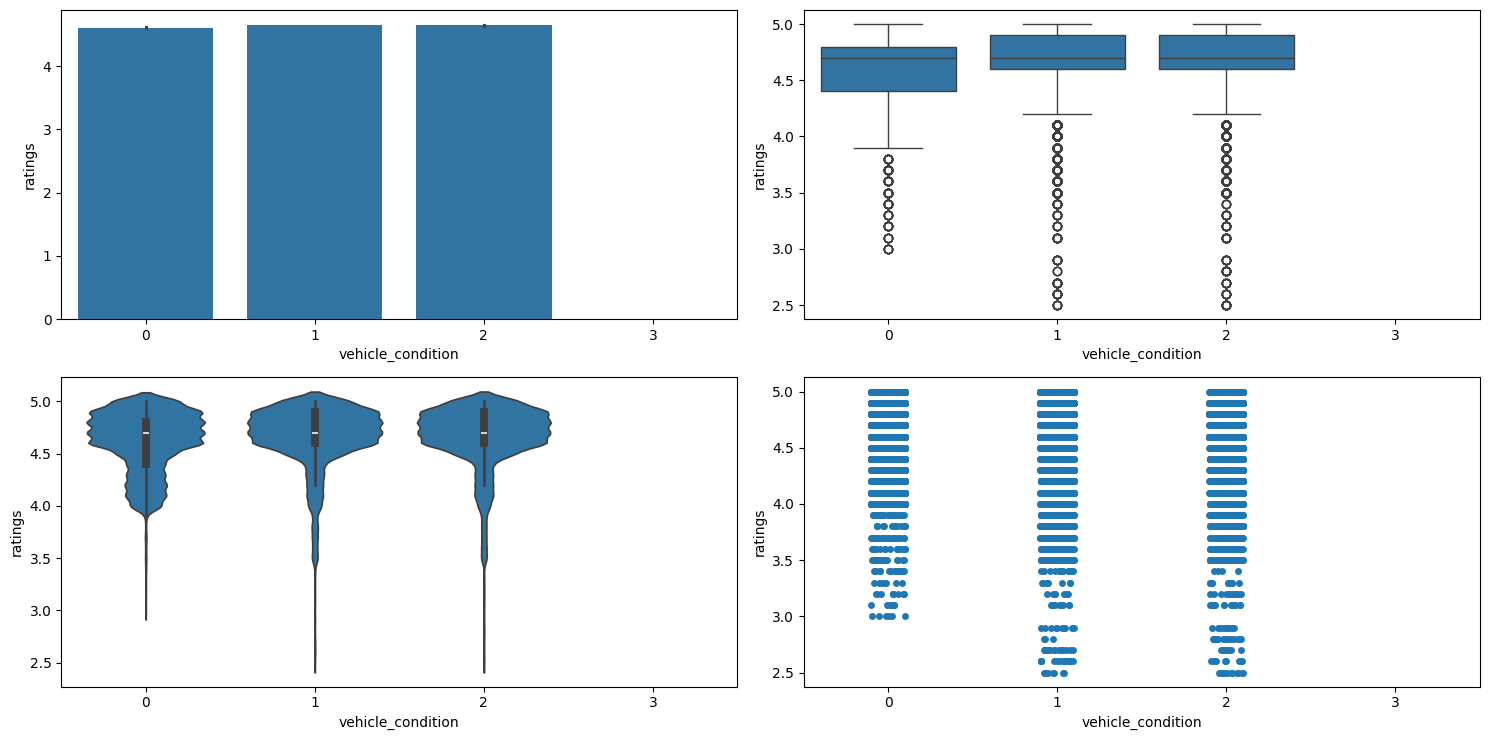

In [33]:
numerical_categorical_analysis(df_final, 'vehicle_condition', 'ratings')

Yes they do

The more worst the vehicle condition is, the more lower the rating gets.
The category 3 has no data means there are NaN values. This simply means that customers avoid rating their riders even rating of 1 when the vehicle condition is bad.

In [36]:
df_final.columns

Index(['rider_id', 'age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'order_date', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'time_taken', 'city_name', 'order_day', 'order_month',
       'order_day_of_week', 'is_weekend', 'pickup_time_minutes',
       'order_time_hour', 'order_time_of_day', 'distance'],
      dtype='object')

In [34]:
(
    df_final[["ratings","vehicle_condition"]]
    .loc[df_final["vehicle_condition"]==3,"ratings"]
    .value_counts(dropna=False)
)

,count
ratings,
NaN,429


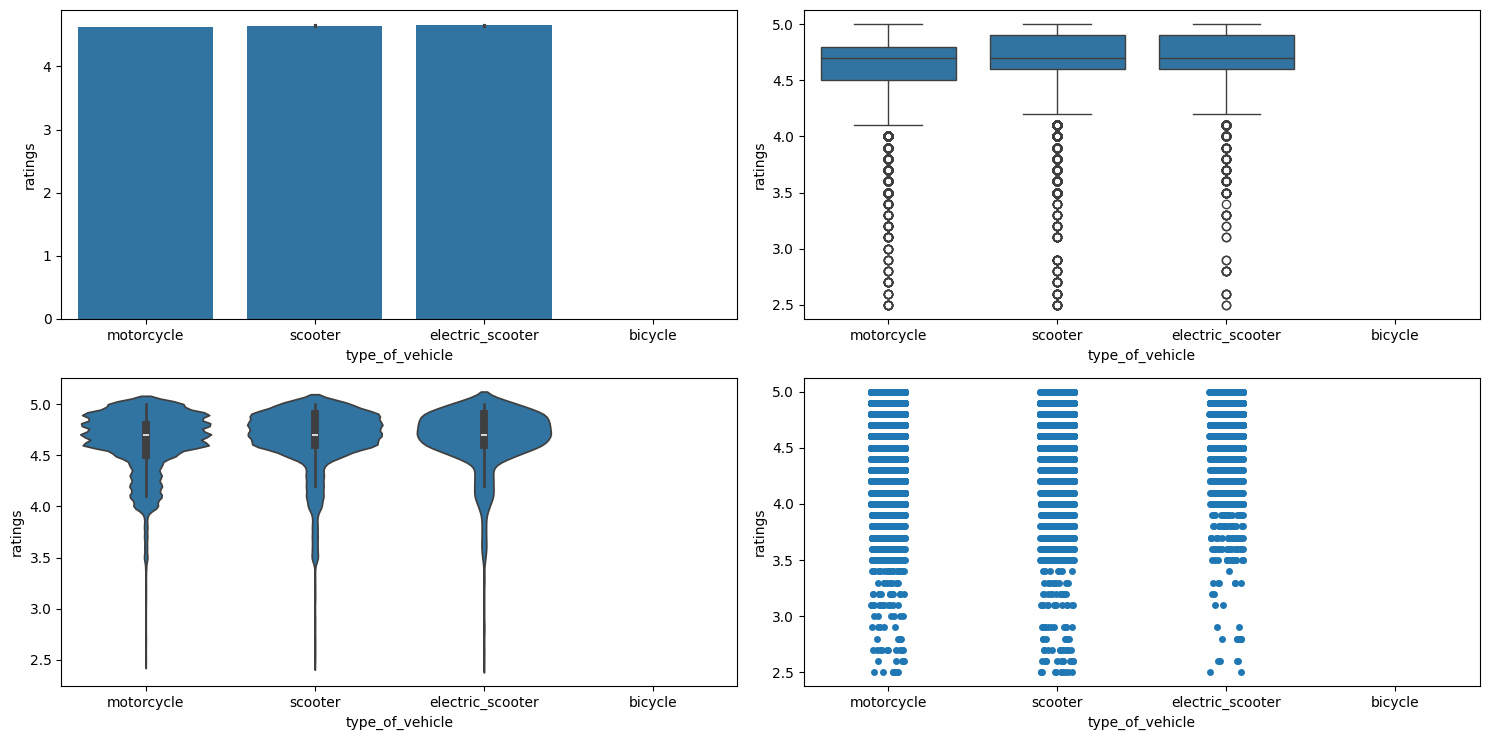

In [37]:
numerical_categorical_analysis(df_final, 'type_of_vehicle', 'ratings')

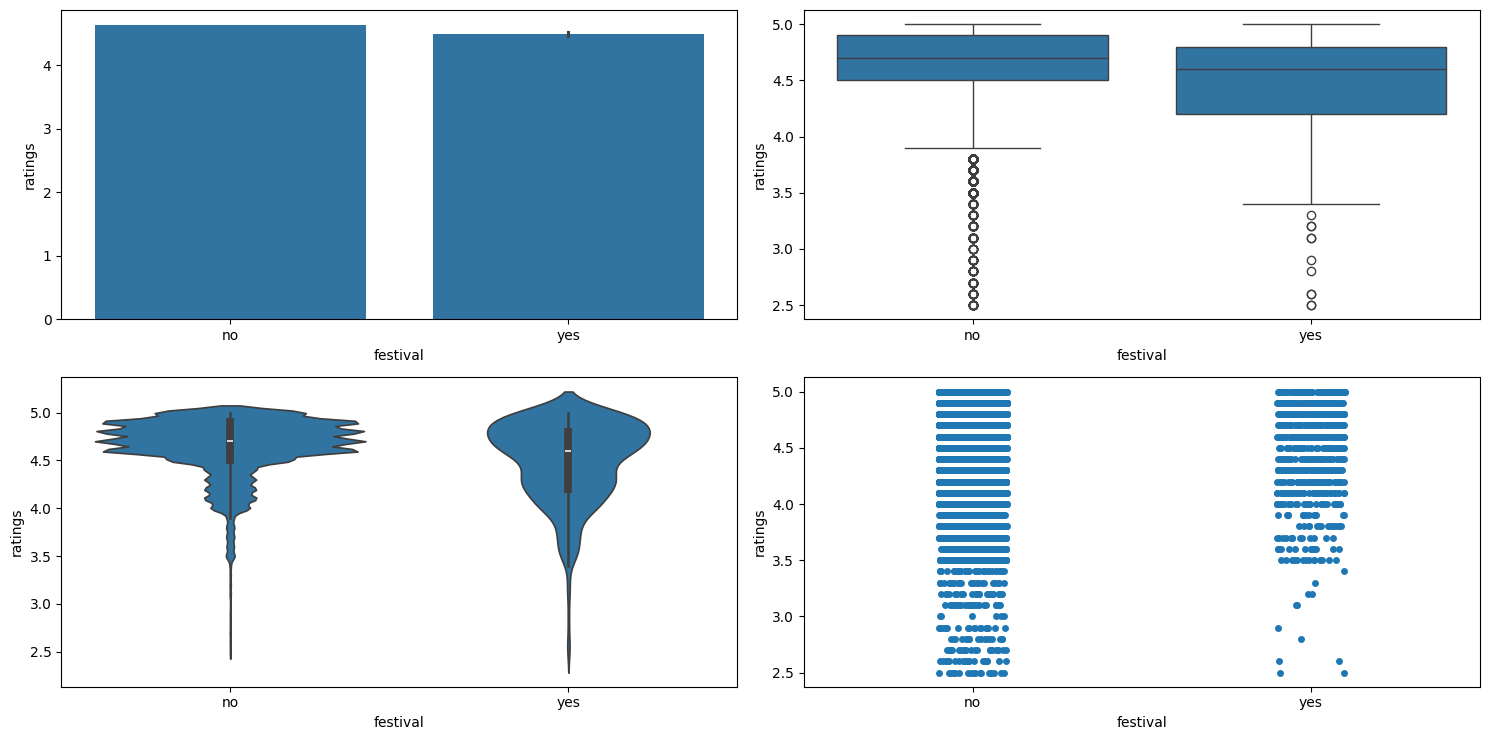

In [38]:
numerical_categorical_analysis(df_final, 'festival', 'ratings')

## Location Based Features

In [39]:
df_final.columns[3:7].tolist() + ["city_name"]

['restaurant_latitude',
 'restaurant_longitude',
 'delivery_latitude',
 'delivery_longitude',
 'city_name']

In [42]:
location_subset = df_final.loc[:,df_final.columns[3:7].tolist() + ["city_name"]]

location_subset

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,city_name
0,22.745049,75.892471,22.765049,75.912471,INDO
1,12.913041,77.683237,13.043041,77.813237,BANG
2,12.914264,77.678400,12.924264,77.688400,BANG
3,11.003669,76.976494,11.053669,77.026494,COIMB
4,12.972793,80.249982,13.012793,80.289982,CHEN
...,...,...,...,...,...
45497,26.902328,75.794257,26.912328,75.804257,JAP
45498,NaN,NaN,NaN,NaN,AGR
45499,13.022394,80.242439,13.052394,80.272439,CHEN
45500,11.001753,76.986241,11.041753,77.026241,COIMB


In [43]:
location_subset.dtypes

,0
restaurant_latitude,float64
restaurant_longitude,float64
delivery_latitude,float64
delivery_longitude,float64
city_name,object


In [45]:
location_subset.isna().sum(axis=0)

,0
restaurant_latitude,3630
restaurant_longitude,3630
delivery_latitude,3630
delivery_longitude,3630
city_name,0


In [46]:
location_subset.dropna(inplace=True)

location_subset

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,city_name
0,22.745049,75.892471,22.765049,75.912471,INDO
1,12.913041,77.683237,13.043041,77.813237,BANG
2,12.914264,77.678400,12.924264,77.688400,BANG
3,11.003669,76.976494,11.053669,77.026494,COIMB
4,12.972793,80.249982,13.012793,80.289982,CHEN
...,...,...,...,...,...
45496,23.371292,85.327872,23.481292,85.437872,RANCHI
45497,26.902328,75.794257,26.912328,75.804257,JAP
45499,13.022394,80.242439,13.052394,80.272439,CHEN
45500,11.001753,76.986241,11.041753,77.026241,COIMB


In [47]:
location_subset.isna().sum(axis=0)

,0
restaurant_latitude,0
restaurant_longitude,0
delivery_latitude,0
delivery_longitude,0
city_name,0


## Order Date

In [49]:
order_date_subset = df_final.loc[:,["order_date","order_day","order_month","order_day_of_week","is_weekend","festival"]]
order_date_subset

,order_date,order_day,order_month,order_day_of_week,is_weekend,festival
0,2022-03-19,19,3,saturday,1,no
1,2022-03-25,25,3,friday,0,no
2,2022-03-19,19,3,saturday,1,no
3,2022-04-05,5,4,tuesday,0,no
4,2022-03-26,26,3,saturday,1,no
...,...,...,...,...,...,...
45497,2022-03-24,24,3,thursday,0,no
45498,2022-02-16,16,2,wednesday,0,no
45499,2022-03-11,11,3,friday,0,no
45500,2022-03-07,7,3,monday,0,no


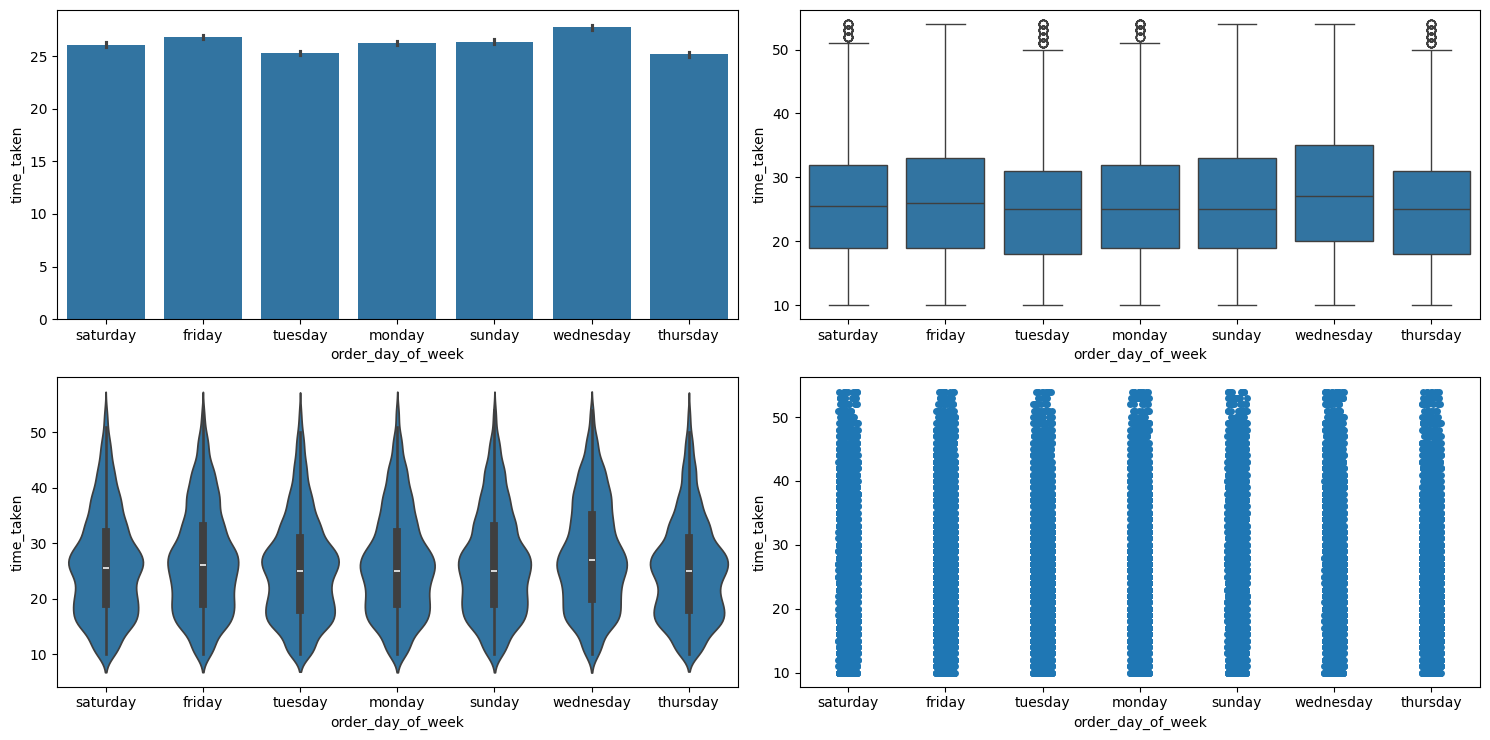

In [50]:
numerical_categorical_analysis(df_final, "order_day_of_week", "time_taken")

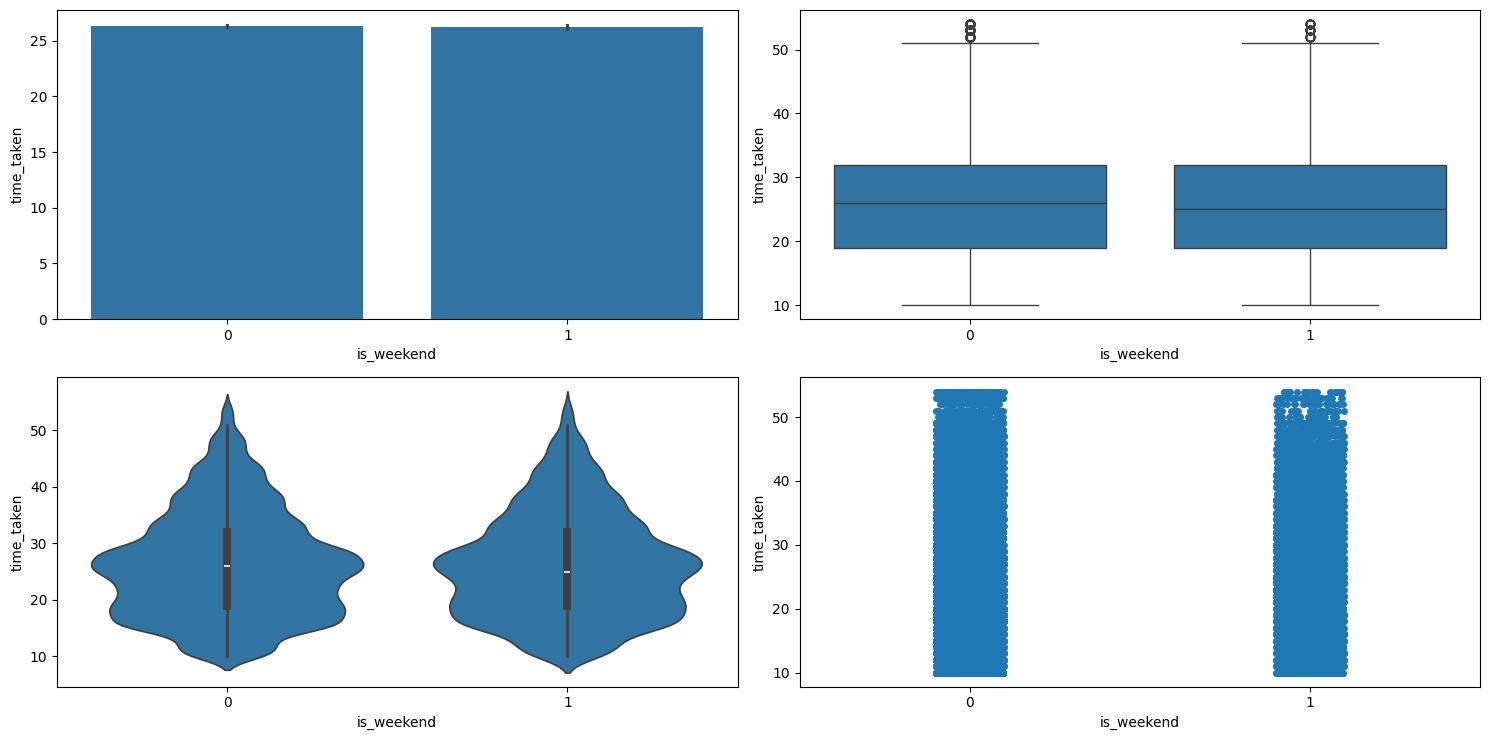

In [51]:
numerical_categorical_analysis(df_final, "is_weekend", "time_taken")

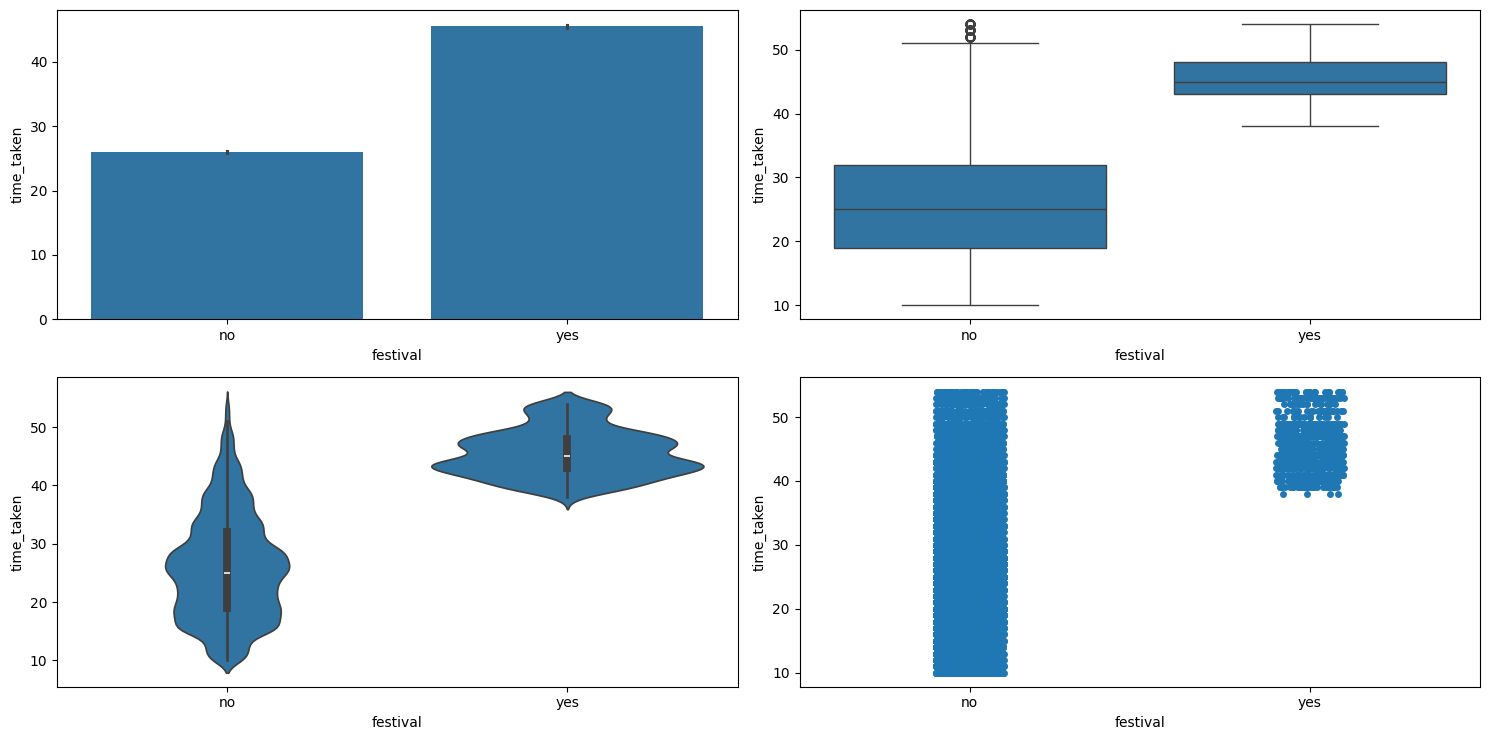

In [52]:
numerical_categorical_analysis(df_final, "festival", "time_taken")

Observations:

The avg time it takes for delivery varies when there is a festival.
The range of delivery time is shorter when there is a festival with lesser variation, which means on a festival delivery times usually takes longer.

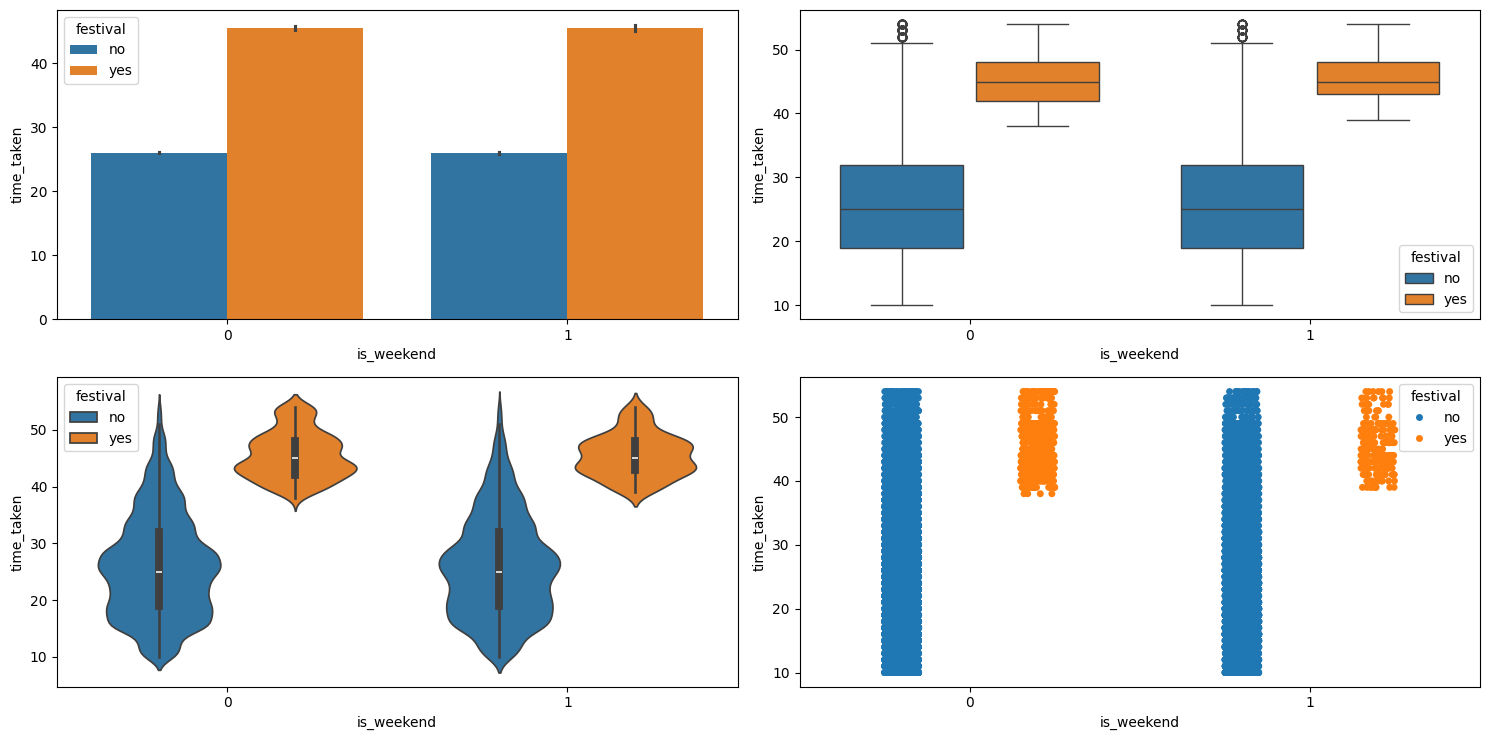

In [56]:
multivariate_analysis(df_final, "time_taken", "is_weekend", "festival")

## Order Time

In [57]:
order_subset= df_final.loc[:, ["order_time_hour","order_time_of_day","pickup_time_minutes"]]
order_subset

,order_time_hour,order_time_of_day,pickup_time_minutes
0,11.0,morning,15.0
1,19.0,evening,5.0
2,8.0,morning,15.0
3,18.0,evening,10.0
4,13.0,afternoon,15.0
...,...,...,...
45497,11.0,morning,10.0
45498,19.0,evening,15.0
45499,23.0,night,15.0
45500,13.0,afternoon,5.0


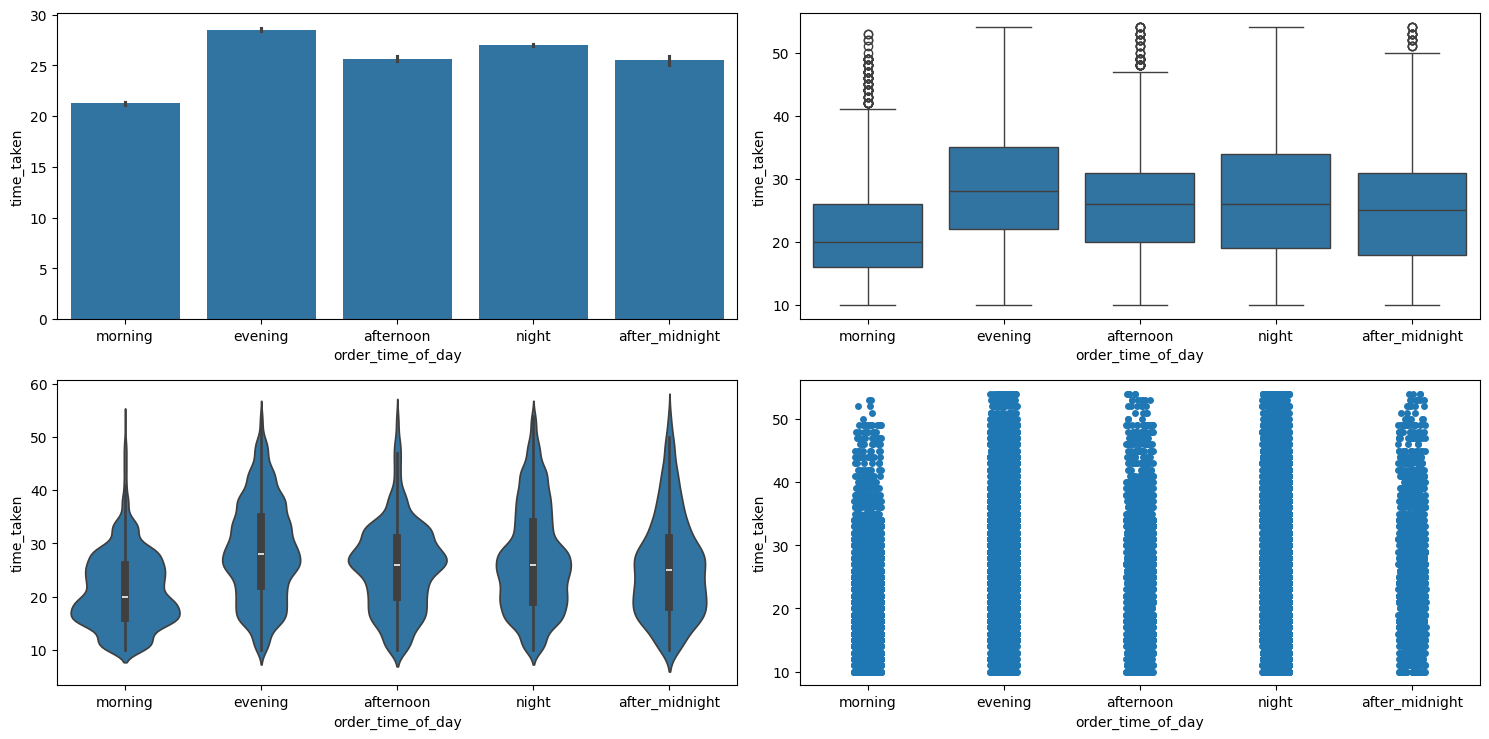

In [58]:
numerical_categorical_analysis(df_final, "order_time_of_day", "time_taken")

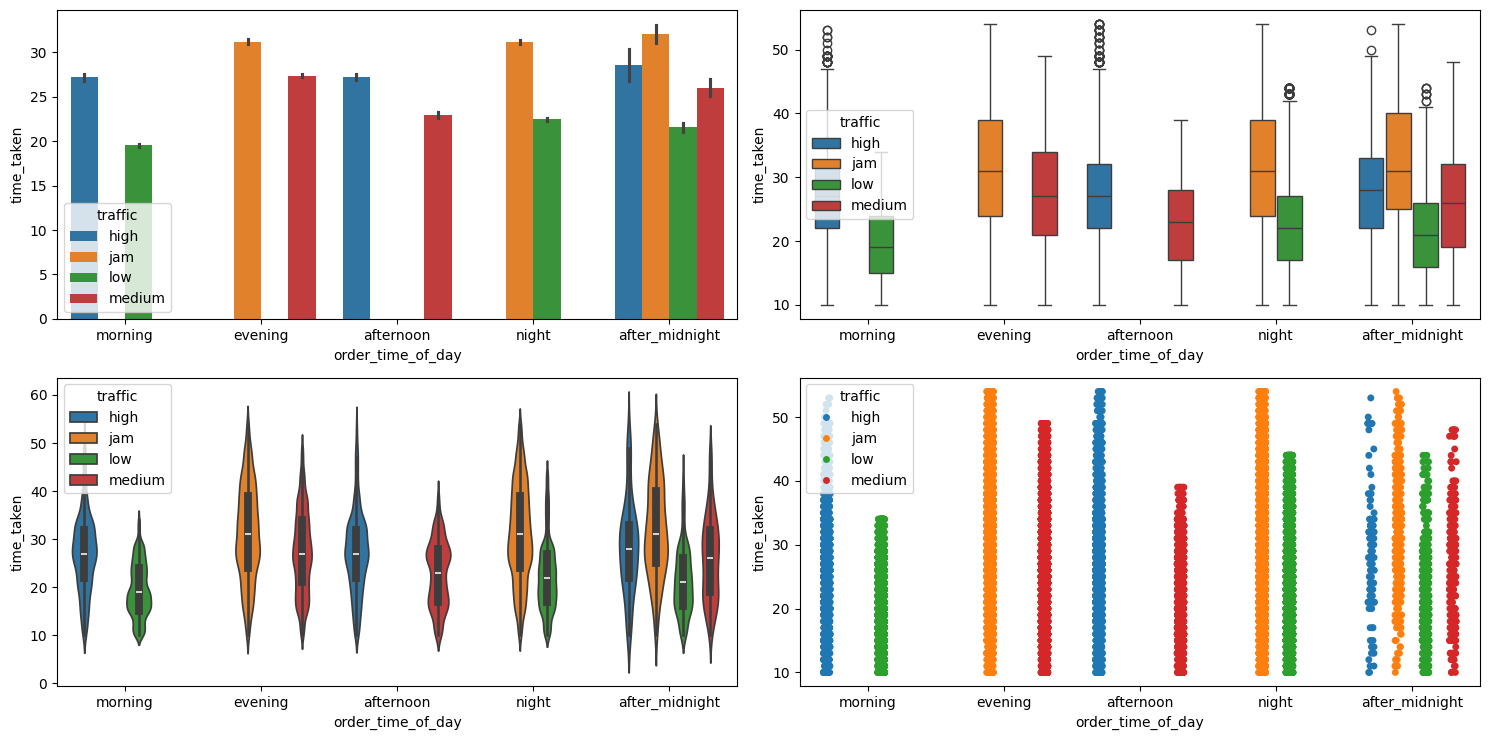

In [59]:
multivariate_analysis(df_final, "time_taken", "order_time_of_day", "traffic")

## Pickup Time

In [61]:
df_final["pickup_time_minutes"].value_counts()

,count
pickup_time_minutes,
5.0,14703
15.0,14610
10.0,14549


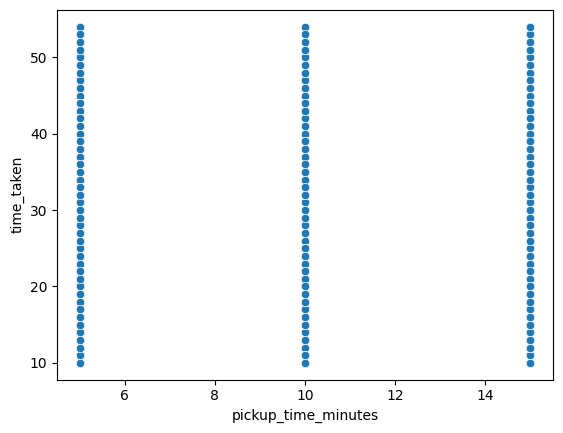

In [60]:
sns.scatterplot(df_final,x="pickup_time_minutes",y="time_taken")
plt.show()

,Count,Percentage
pickup_time_minutes,,
5.0,14703,33.52%
15.0,14610,33.31%
10.0,14549,33.17%


**************************************************
The unique categories in pickup_time_minutes column are [15.0, 5.0, 10.0, nan]
**************************************************
The number of categories in pickup_time_minutes column are 3


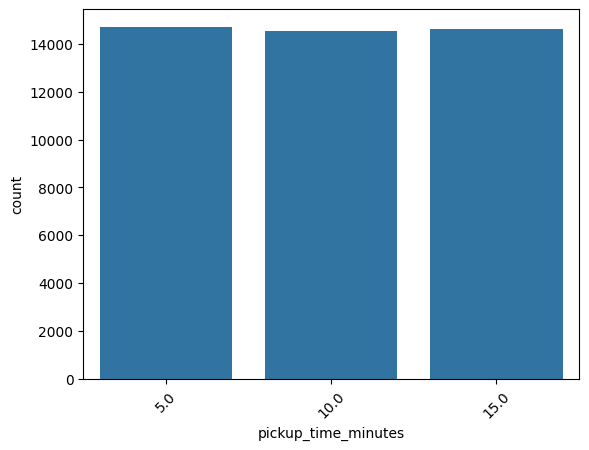

In [62]:
categorical_analysis(df_final, "pickup_time_minutes")

Convert the column to ordinal categorical column

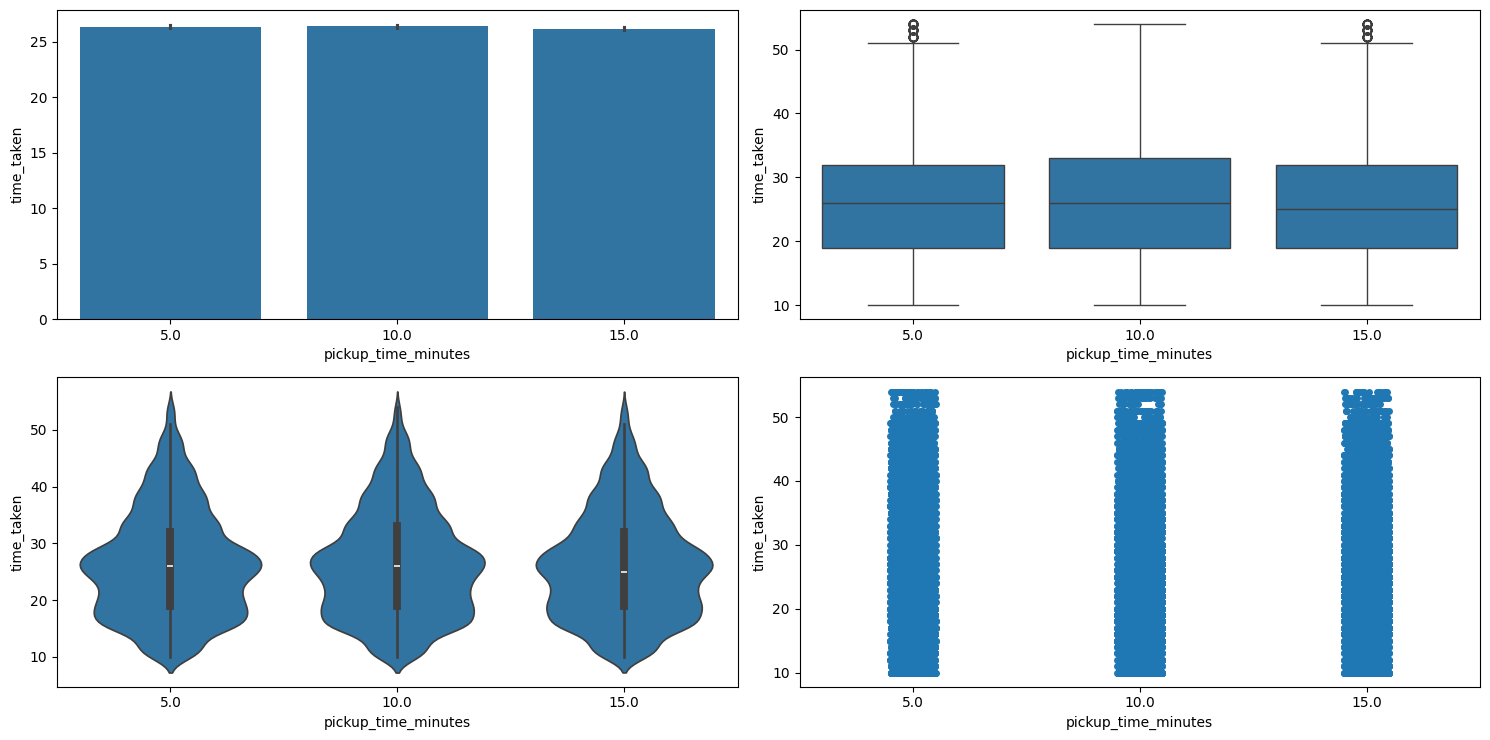

In [63]:
numerical_categorical_analysis(df_final, "pickup_time_minutes", "time_taken")

***Traffic***



,Count,Percentage
traffic,,
low,15477,34.4%
jam,14143,31.43%
medium,10947,24.33%
high,4425,9.84%


**************************************************
The unique categories in traffic column are ['high', 'jam', 'low', 'medium', nan]
**************************************************
The number of categories in traffic column are 4


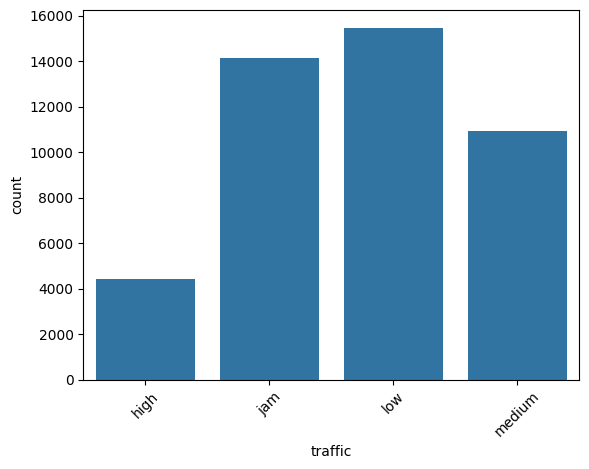

In [64]:
categorical_analysis(df_final, "traffic")

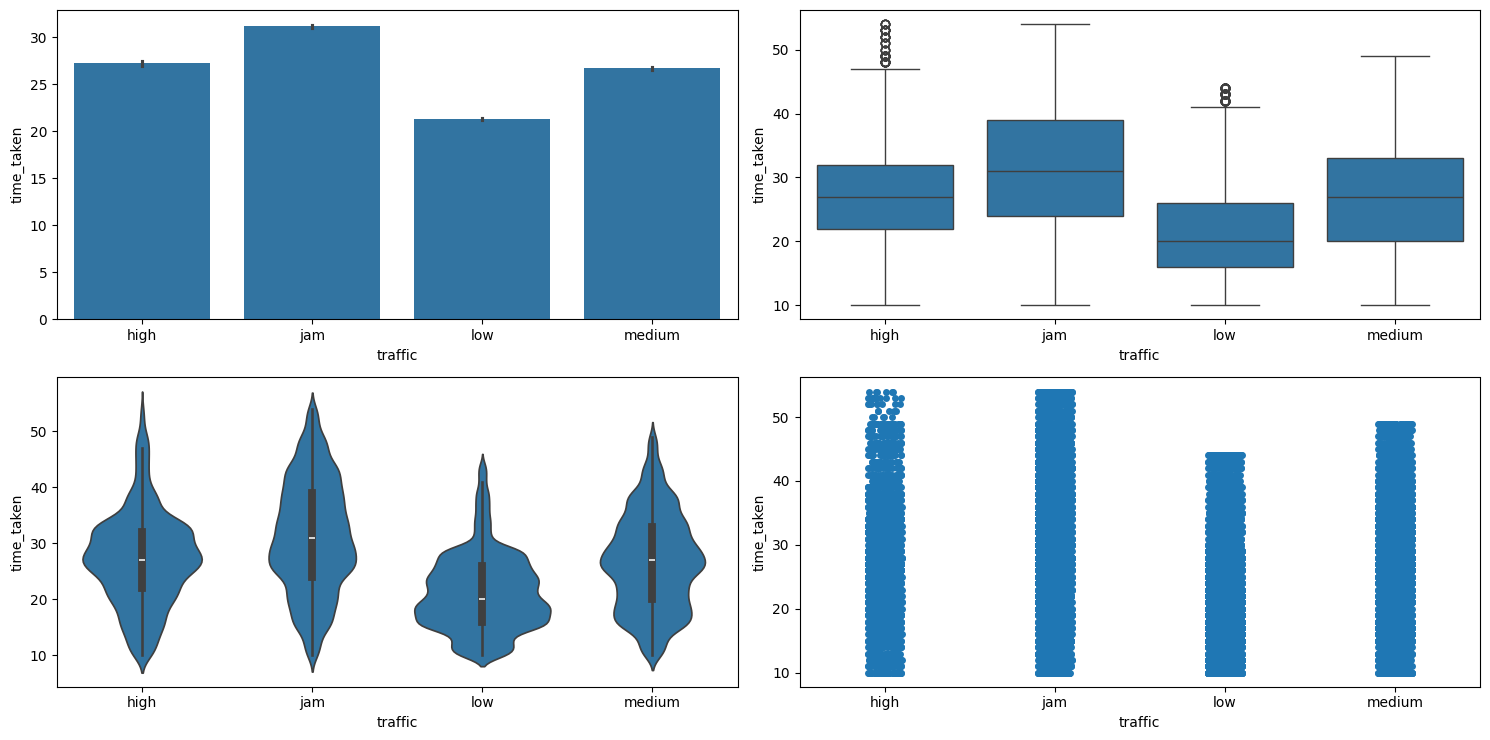

In [65]:
numerical_categorical_analysis(df_final, "traffic", "time_taken")

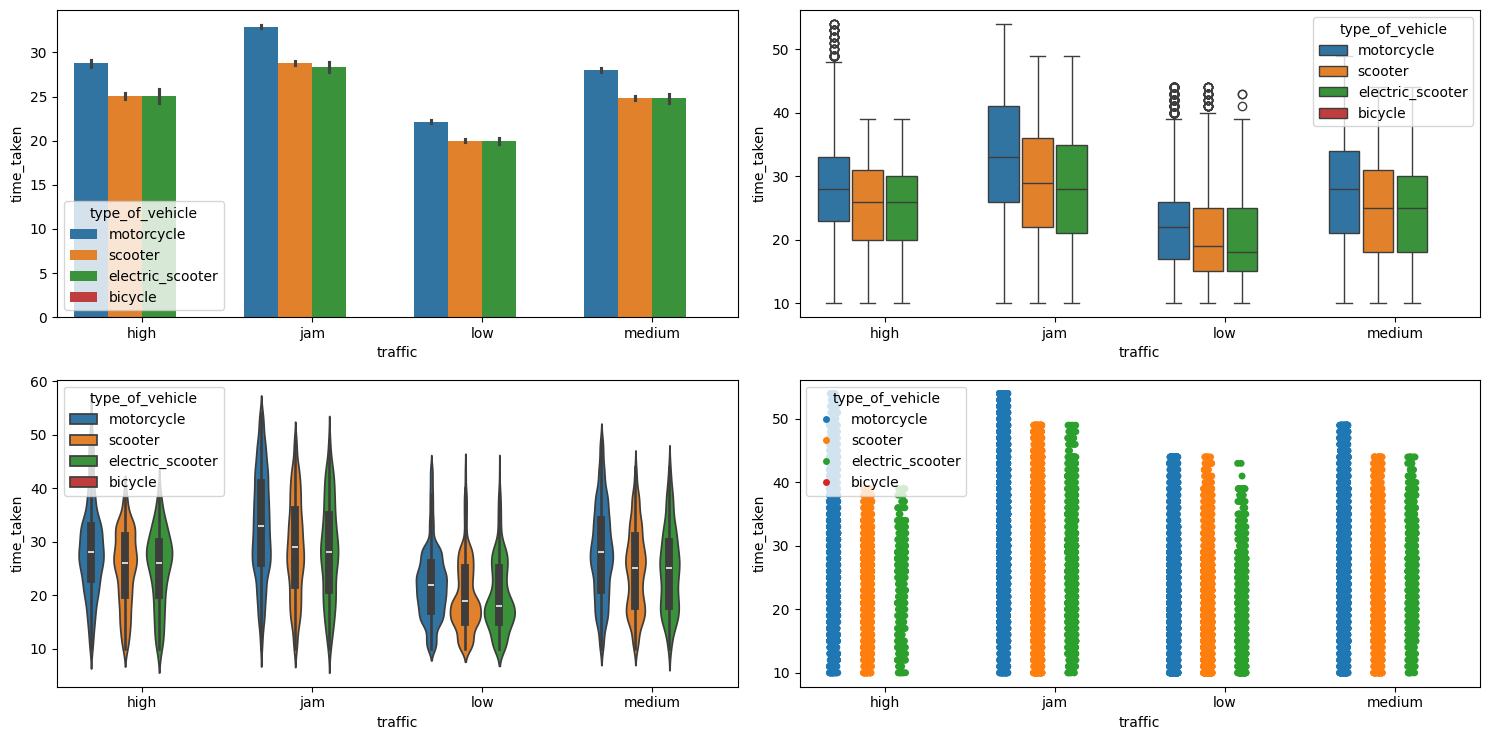

In [66]:
multivariate_analysis(df_final, "time_taken", "traffic", "type_of_vehicle")

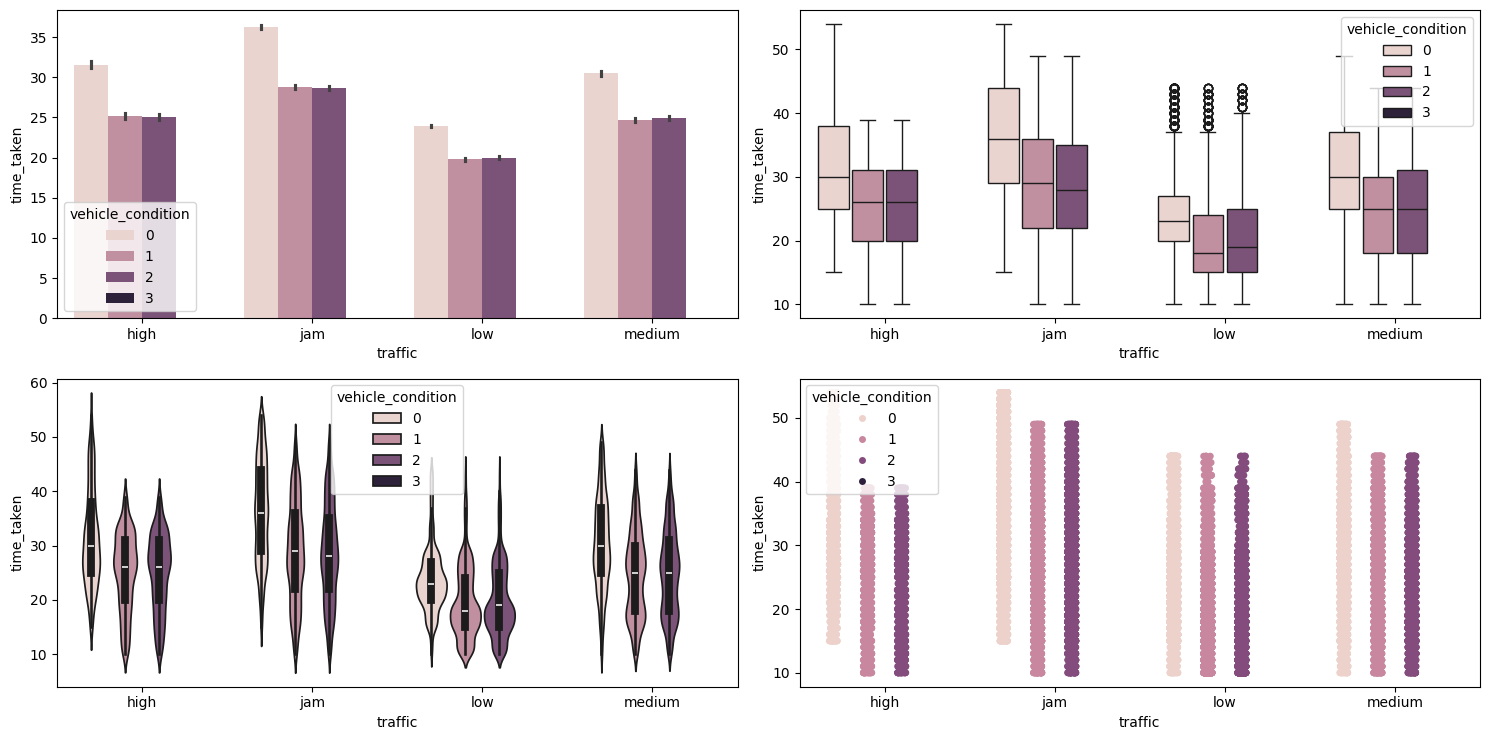

In [67]:
multivariate_analysis(df_final, "time_taken", "traffic", "vehicle_condition")

**Dont make wrong interpretations that good condition vehicles takes longer times on avg**

This simply means that good vehicles are preferred for deliveries during festivals which results in longer delivery times

## Multiple Deliveries

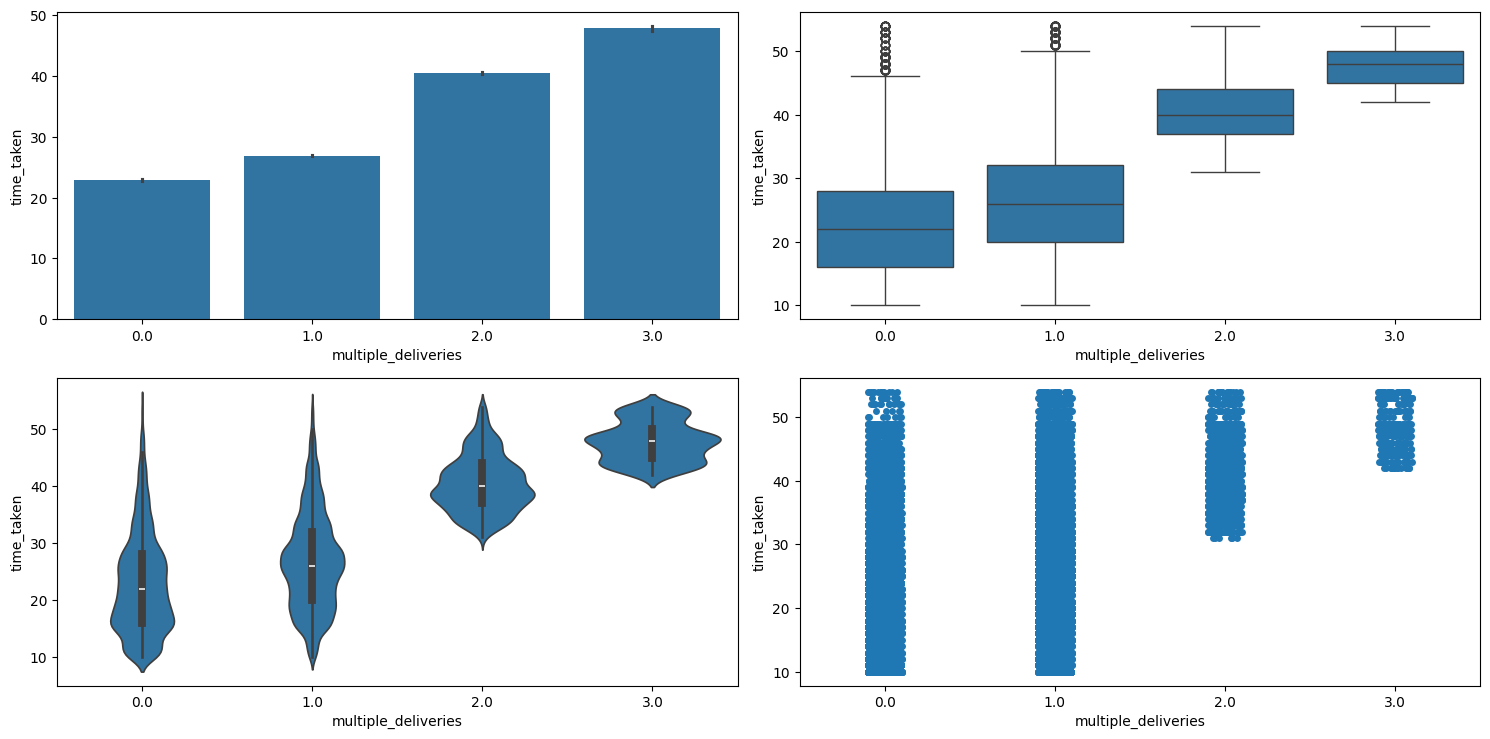

In [68]:
numerical_categorical_analysis(df_final, "multiple_deliveries", "time_taken")

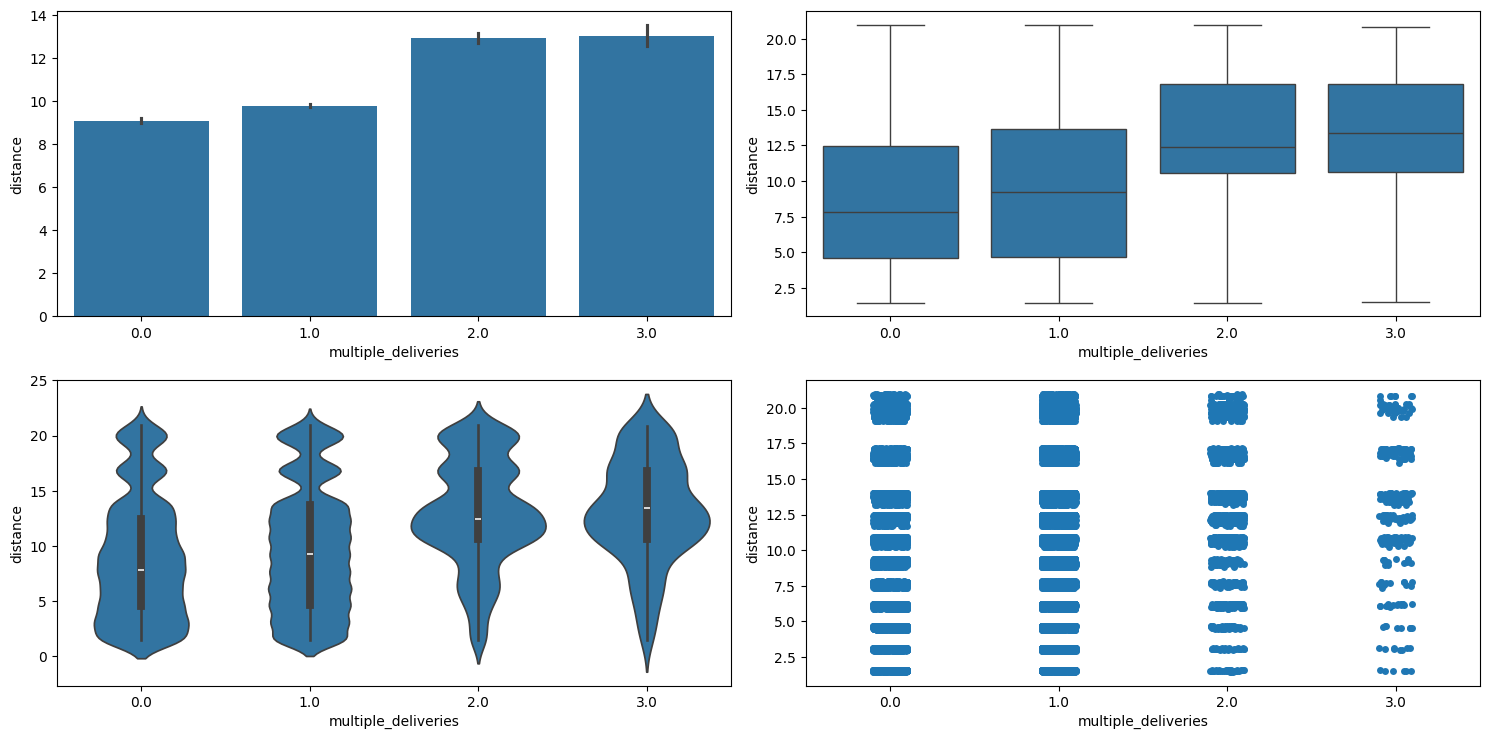

In [69]:
numerical_categorical_analysis(df_final, "multiple_deliveries", "distance")

## Weather

,Count,Percentage
weather,,
fog,7654,17.02%
stormy,7586,16.87%
cloudy,7536,16.76%
sandstorms,7495,16.66%
windy,7422,16.5%
sunny,7284,16.19%


**************************************************
The unique categories in weather column are ['sunny', 'stormy', 'sandstorms', 'cloudy', 'fog', 'windy', nan]
**************************************************
The number of categories in weather column are 6


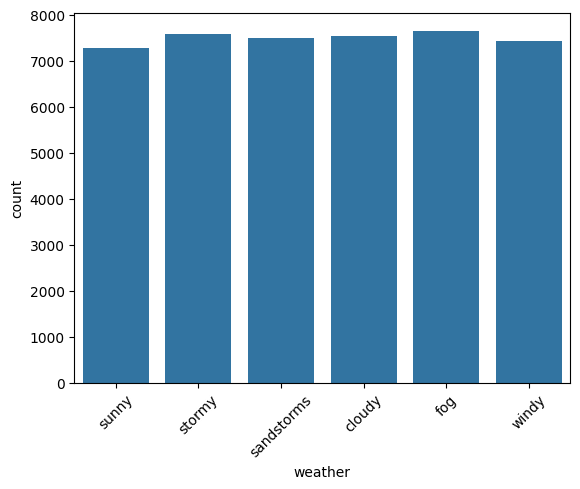

In [70]:
categorical_analysis(df_final, "weather")

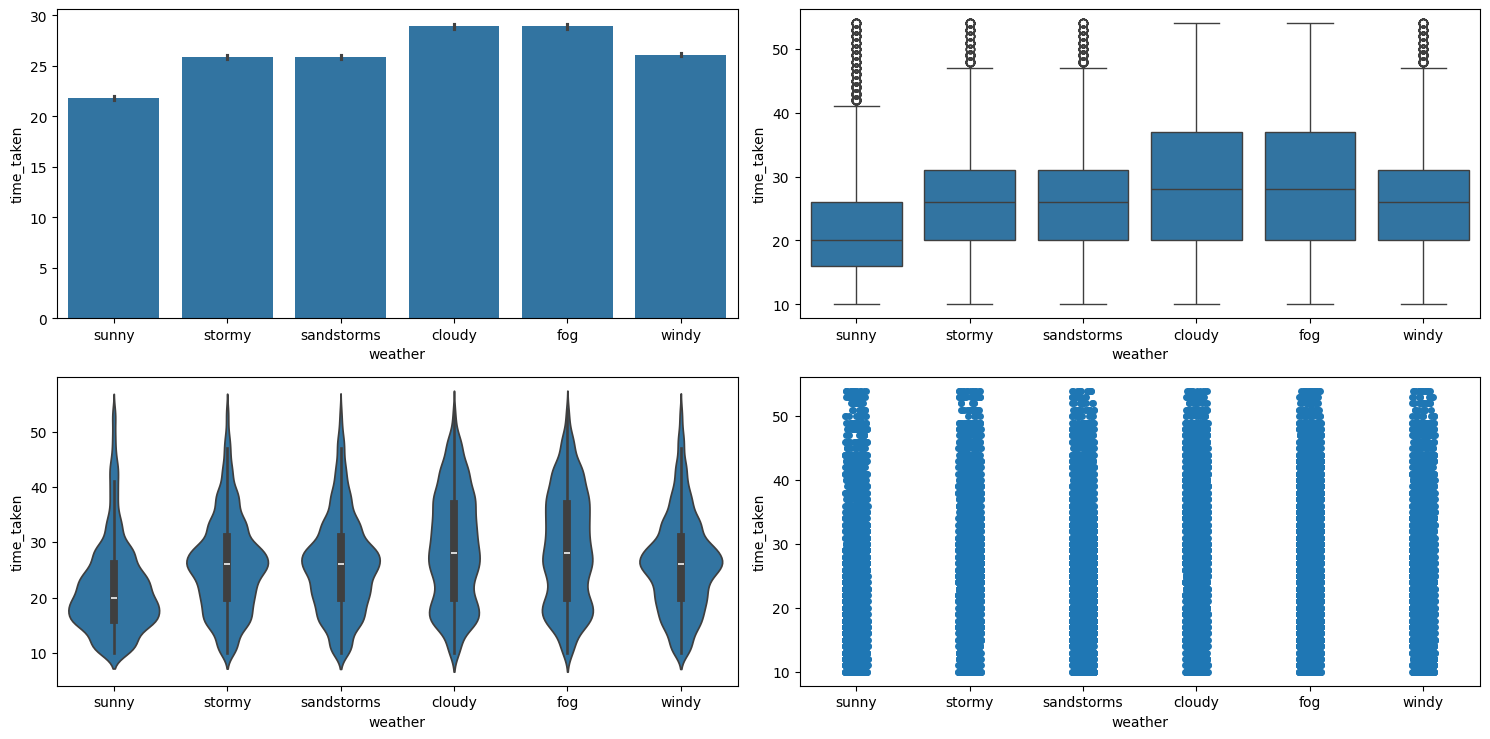

In [71]:
numerical_categorical_analysis(df_final, "weather", "time_taken")

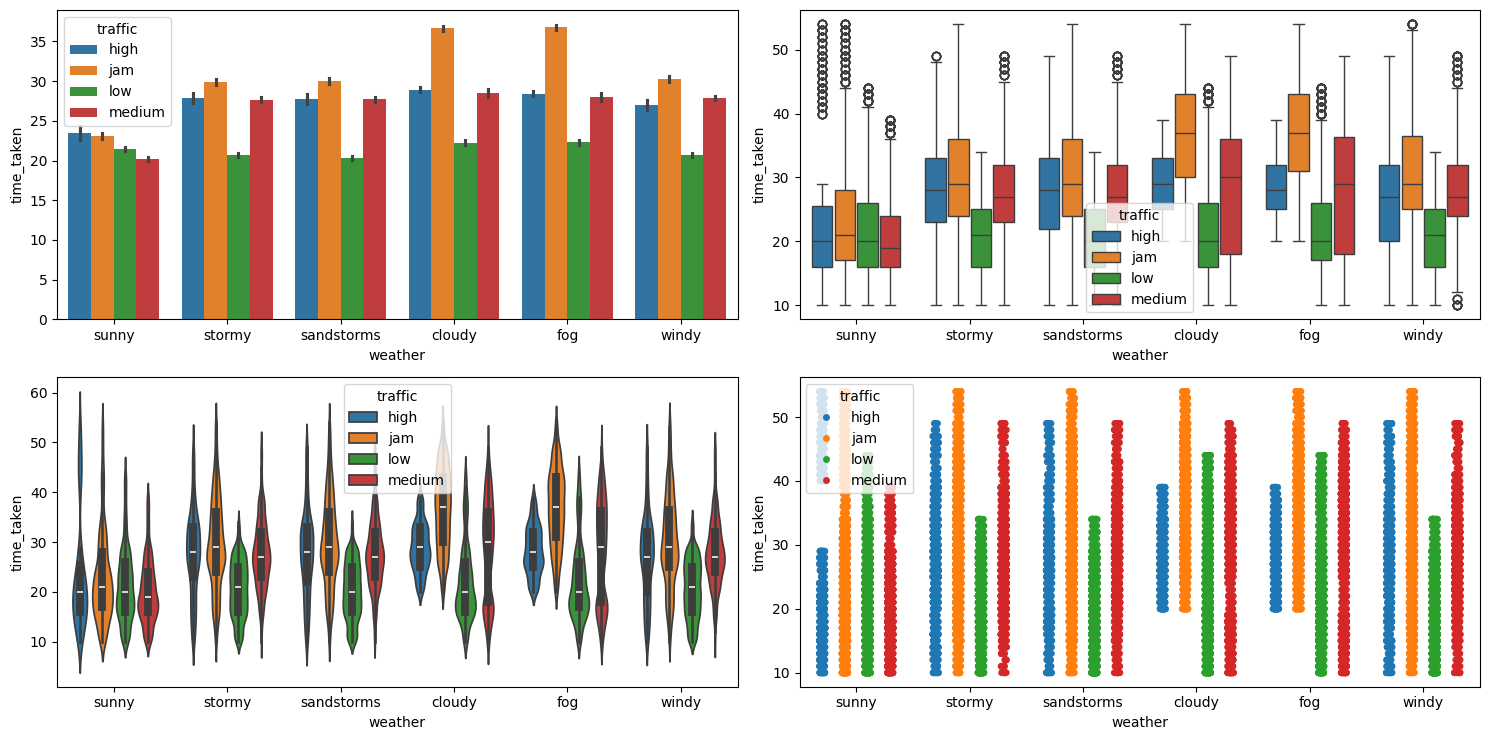

In [72]:
multivariate_analysis(df_final, "time_taken", "weather", "traffic")

## Vehicle - Condition and Type


,Count,Percentage
vehicle_condition,,
2,15034,33.04%
1,15030,33.03%
0,15009,32.99%
3,429,0.94%


**************************************************
The unique categories in vehicle_condition column are [2, 0, 1, 3]
**************************************************
The number of categories in vehicle_condition column are 4


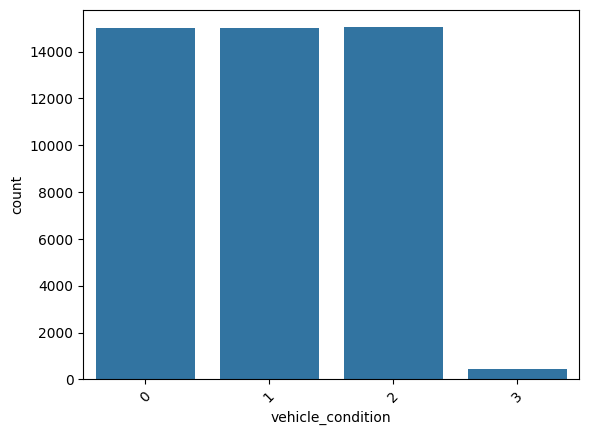

In [73]:
categorical_analysis(df_final, "vehicle_condition")

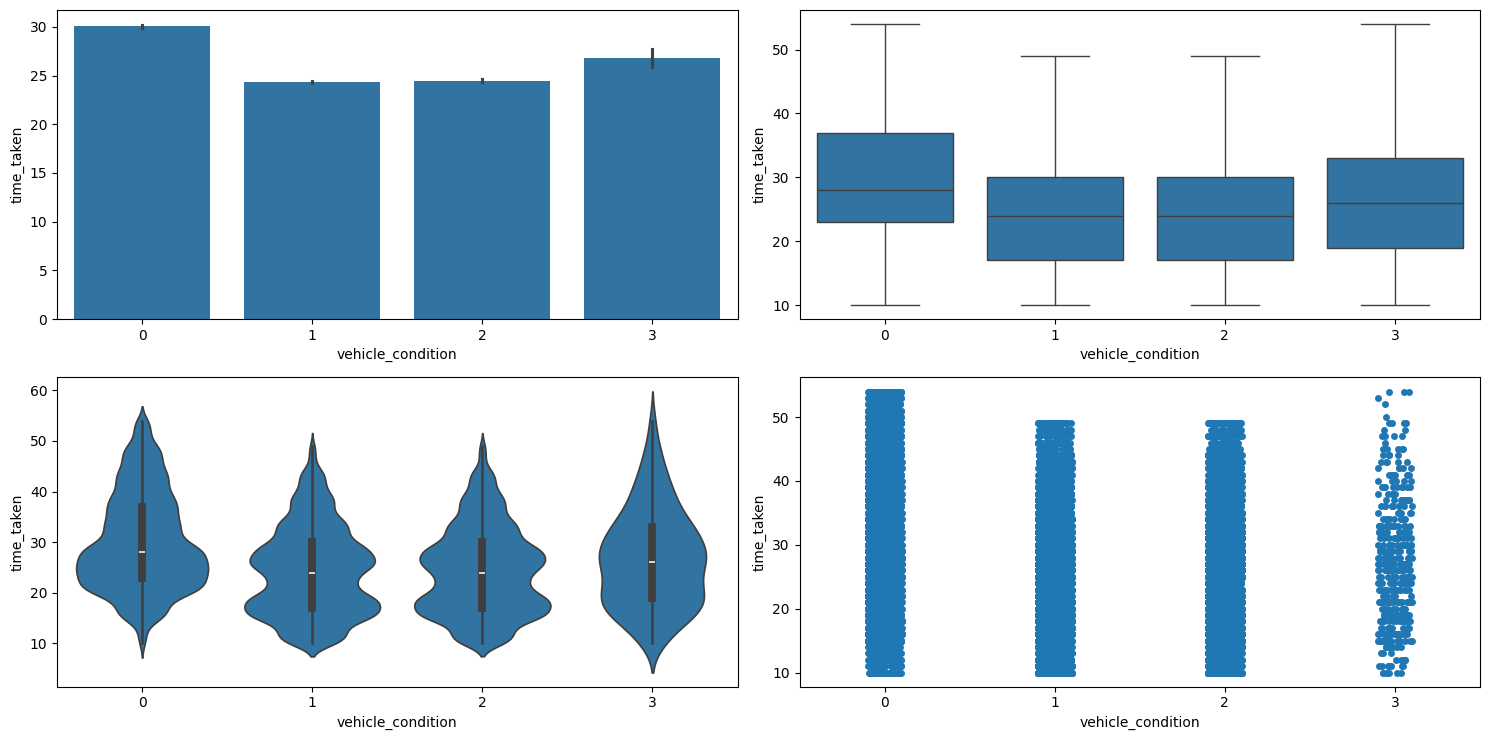

In [74]:
numerical_categorical_analysis(df_final, "vehicle_condition", "time_taken")

,Count,Percentage
type_of_vehicle,,
motorcycle,26427,58.08%
scooter,15244,33.5%
electric_scooter,3778,8.3%
bicycle,53,0.12%


**************************************************
The unique categories in type_of_vehicle column are ['motorcycle', 'scooter', 'electric_scooter', 'bicycle']
**************************************************
The number of categories in type_of_vehicle column are 4


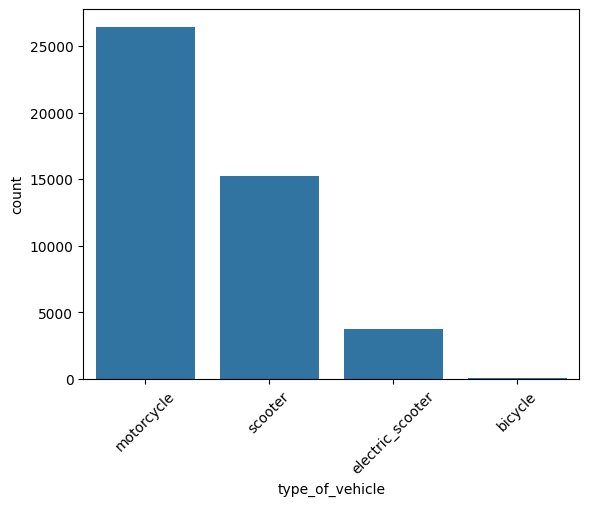

In [75]:
categorical_analysis(df_final, "type_of_vehicle")

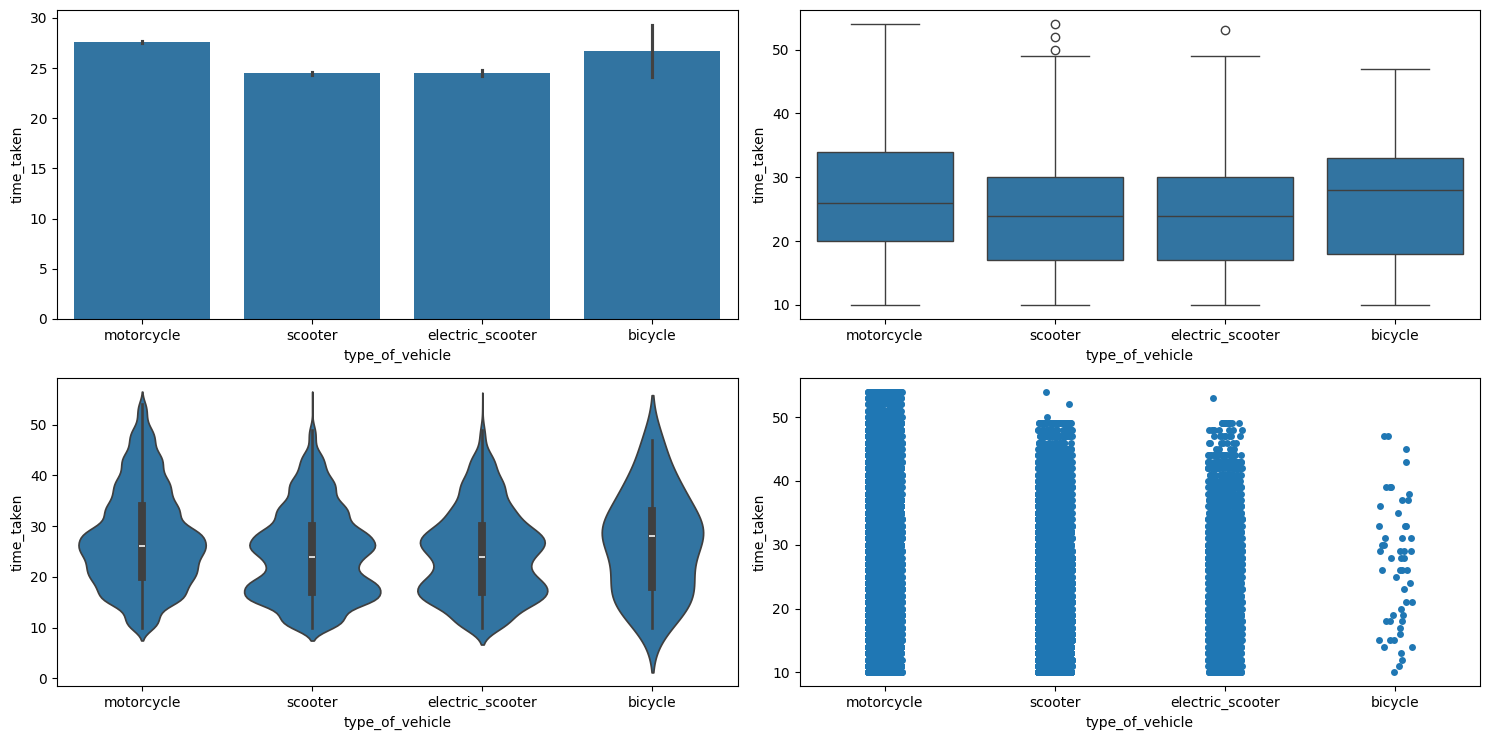

In [76]:
numerical_categorical_analysis(df_final, "type_of_vehicle", "time_taken")

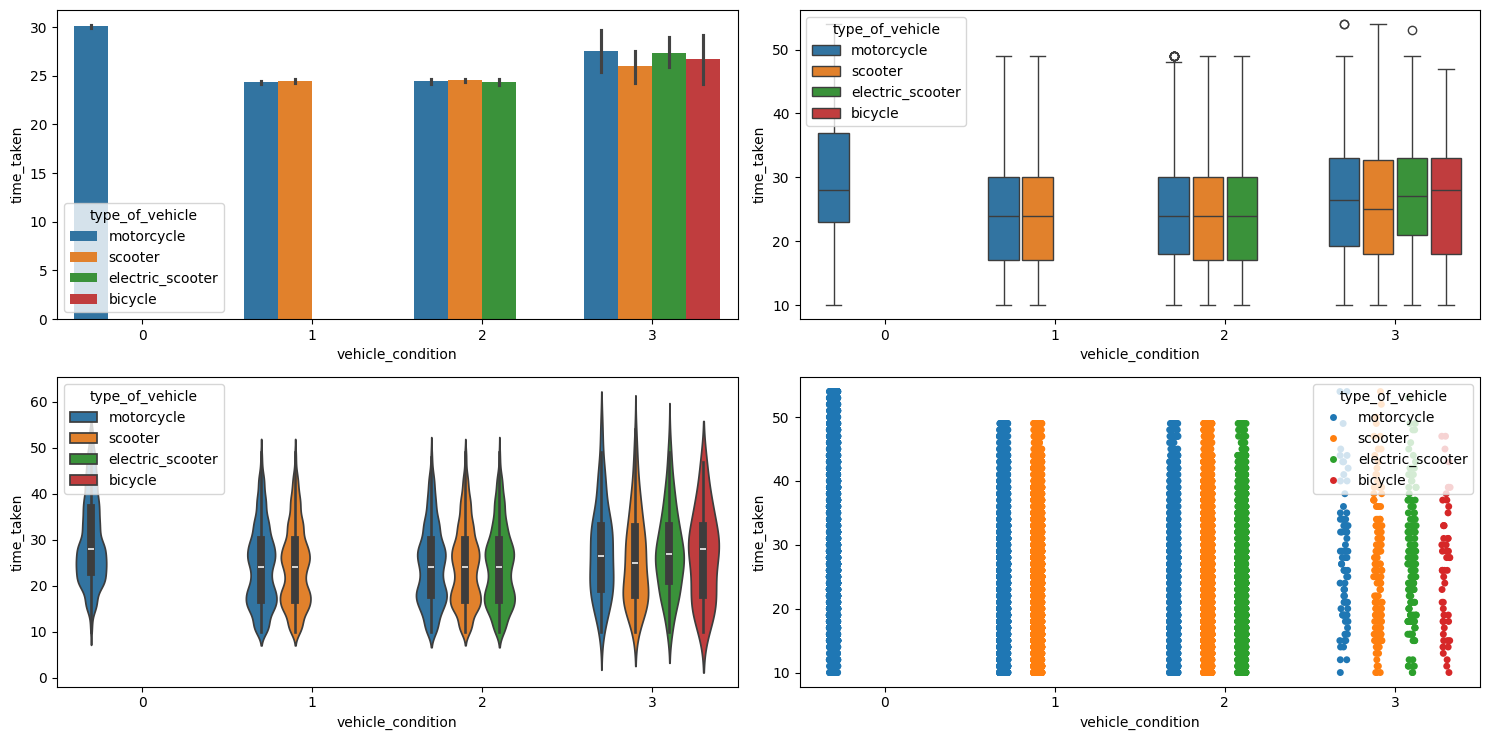

In [77]:
multivariate_analysis(df_final, "time_taken", "vehicle_condition", "type_of_vehicle")

**Type of order**

,Count,Percentage
type_of_order,,
snack,11512,25.3%
meal,11435,25.13%
drinks,11294,24.82%
buffet,11261,24.75%


**************************************************
The unique categories in type_of_order column are ['snack', 'drinks', 'buffet', 'meal']
**************************************************
The number of categories in type_of_order column are 4


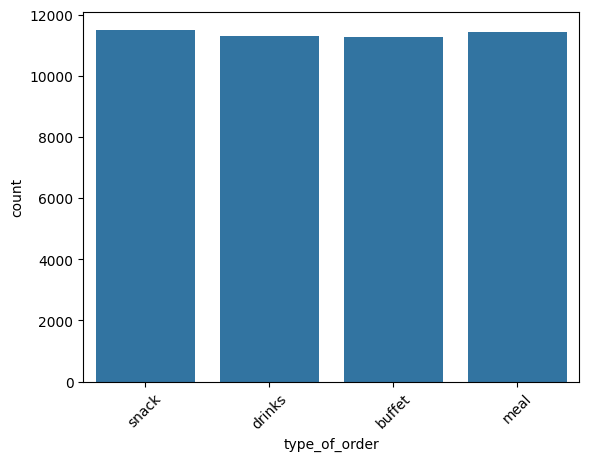

In [78]:
categorical_analysis(df_final, "type_of_order")

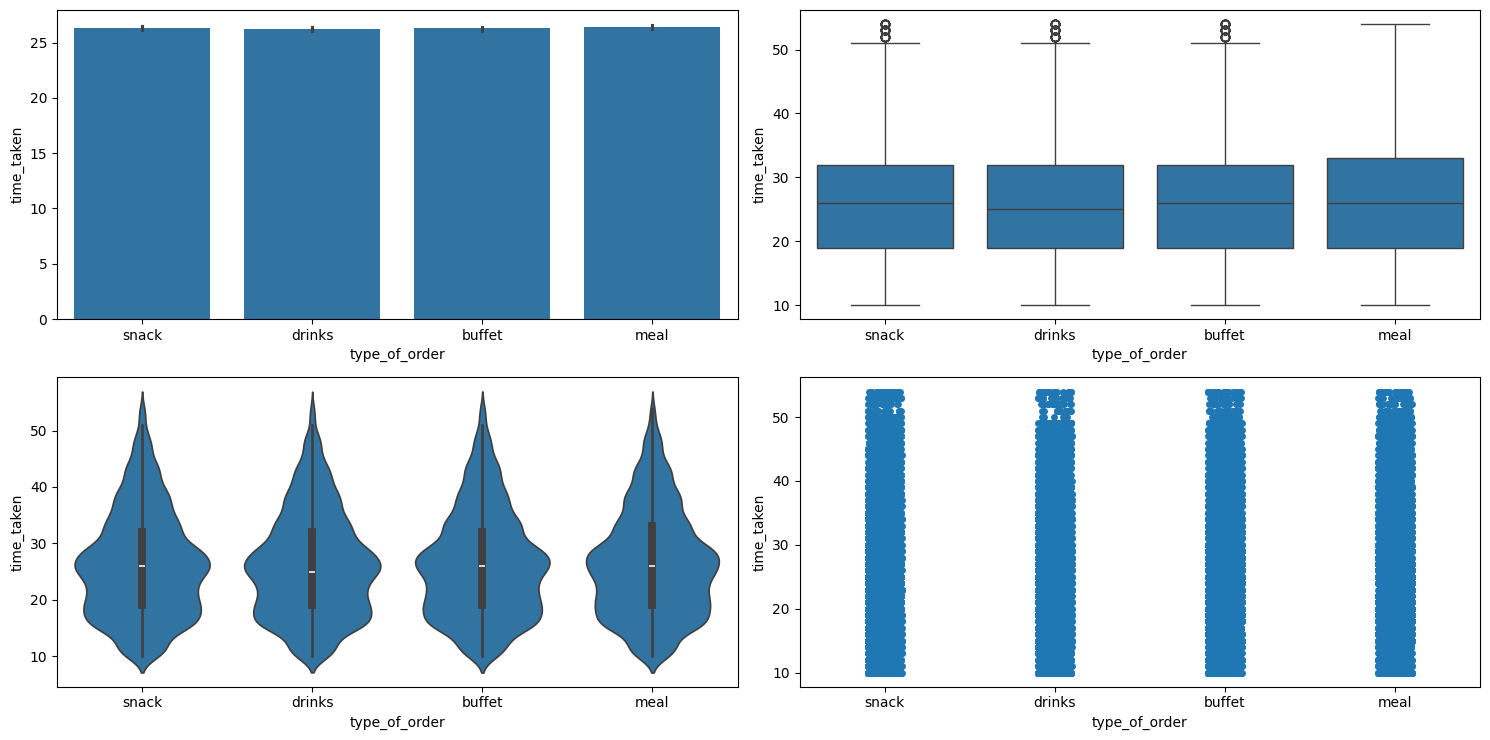

In [79]:
numerical_categorical_analysis(df_final, "type_of_order", "time_taken")

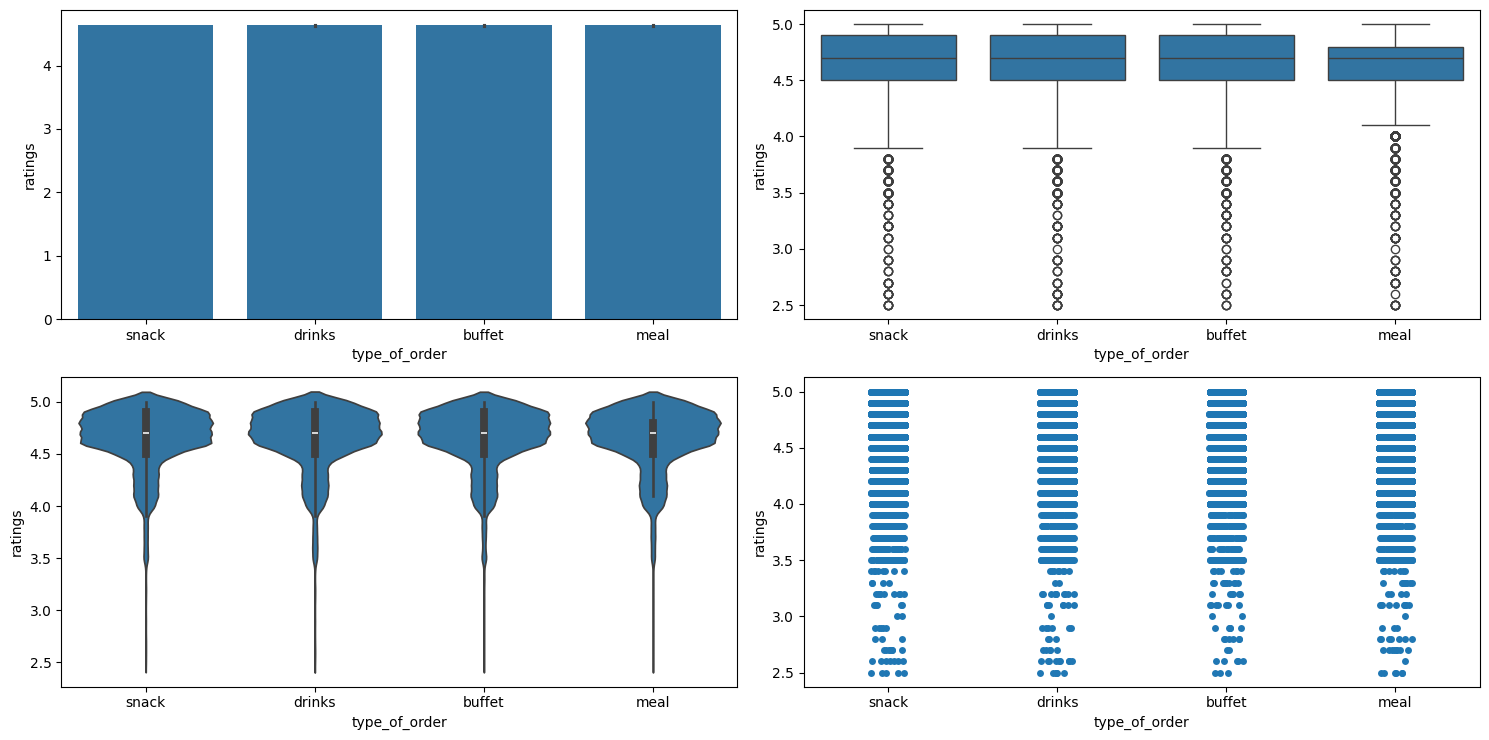

In [80]:
numerical_categorical_analysis(df_final, "type_of_order", "ratings")

,Count,Percentage
city_type,,
metropolitian,34029,76.81%
urban,10111,22.82%
semi-urban,164,0.37%


**************************************************
The unique categories in city_type column are ['urban', 'metropolitian', 'semi-urban', nan]
**************************************************
The number of categories in city_type column are 3


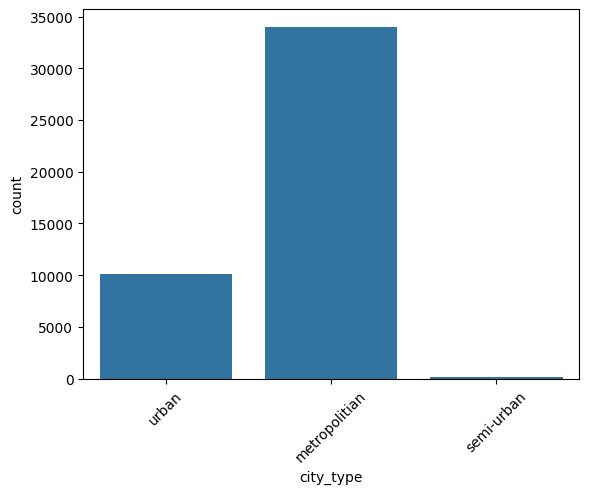

In [81]:
categorical_analysis(df_final, "city_type")

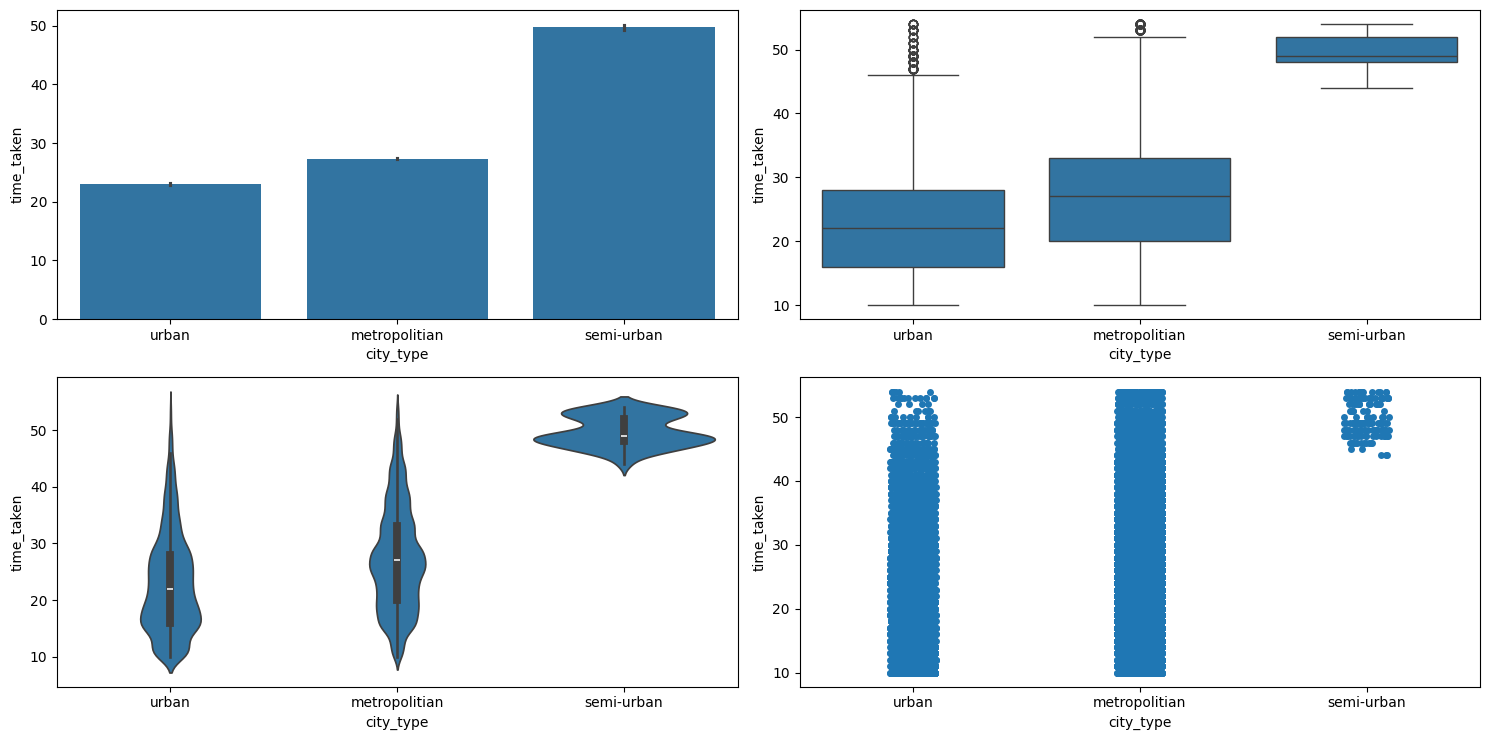

In [82]:
numerical_categorical_analysis(df_final, "city_type", "time_taken")

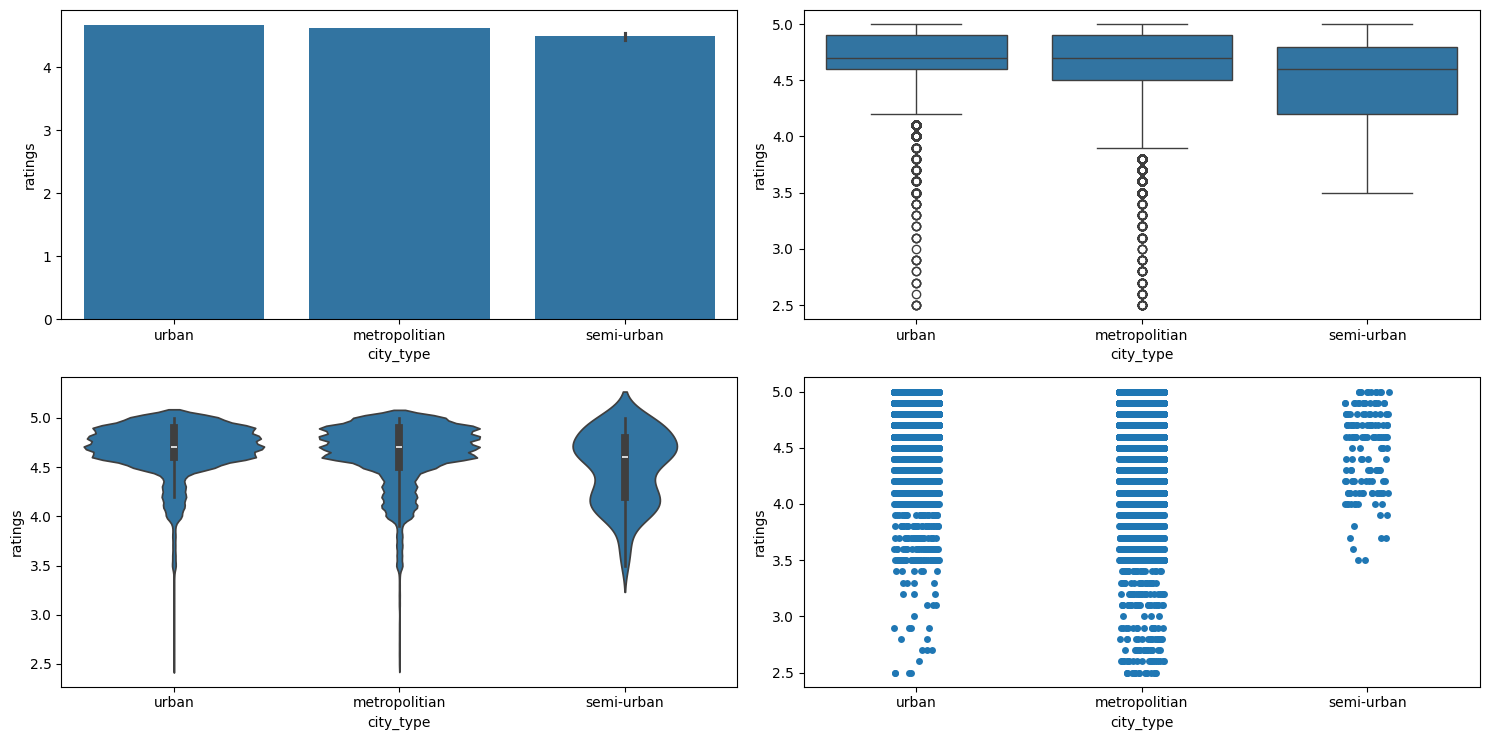

In [83]:
numerical_categorical_analysis(df_final, "city_type", "ratings")

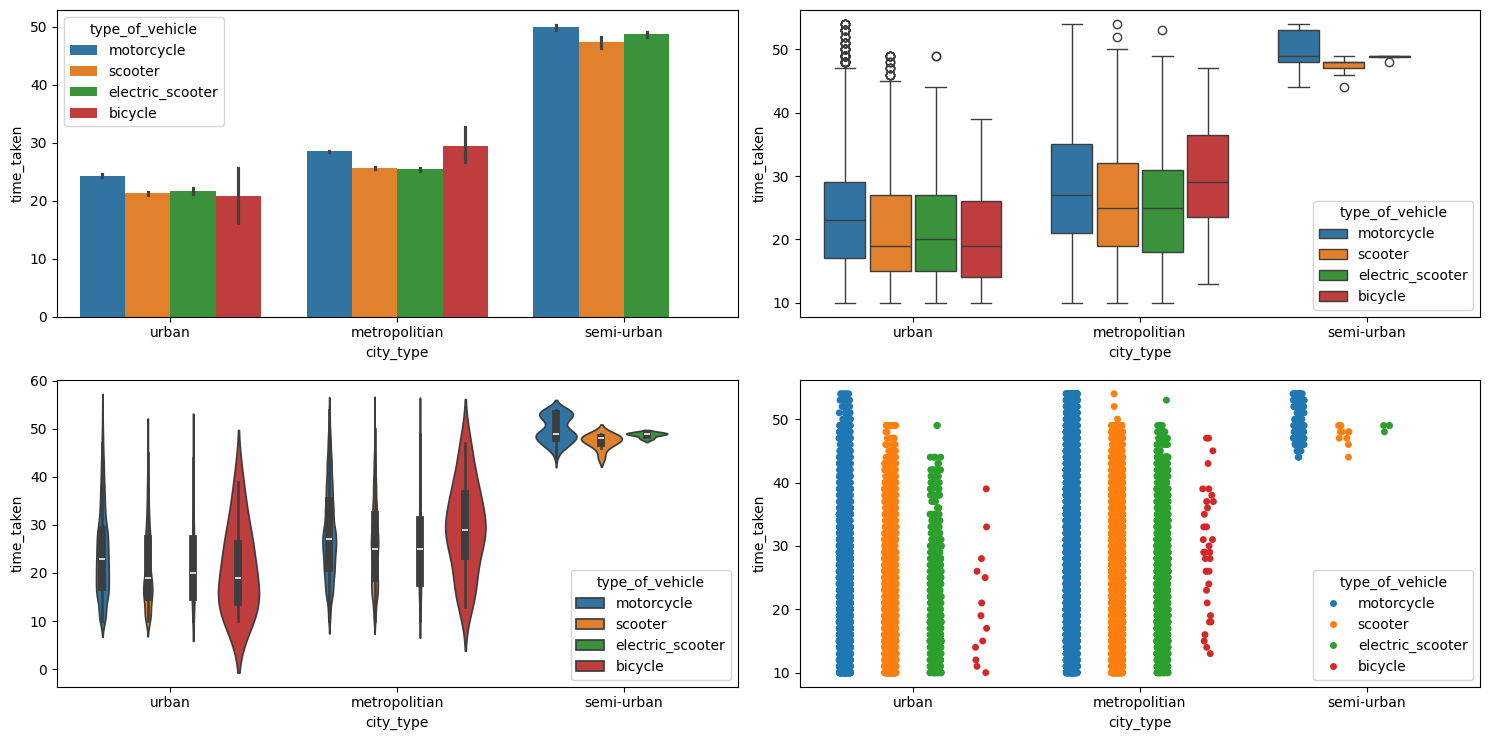

In [84]:
multivariate_analysis(df_final, "time_taken", "city_type", "type_of_vehicle")

*Distance*

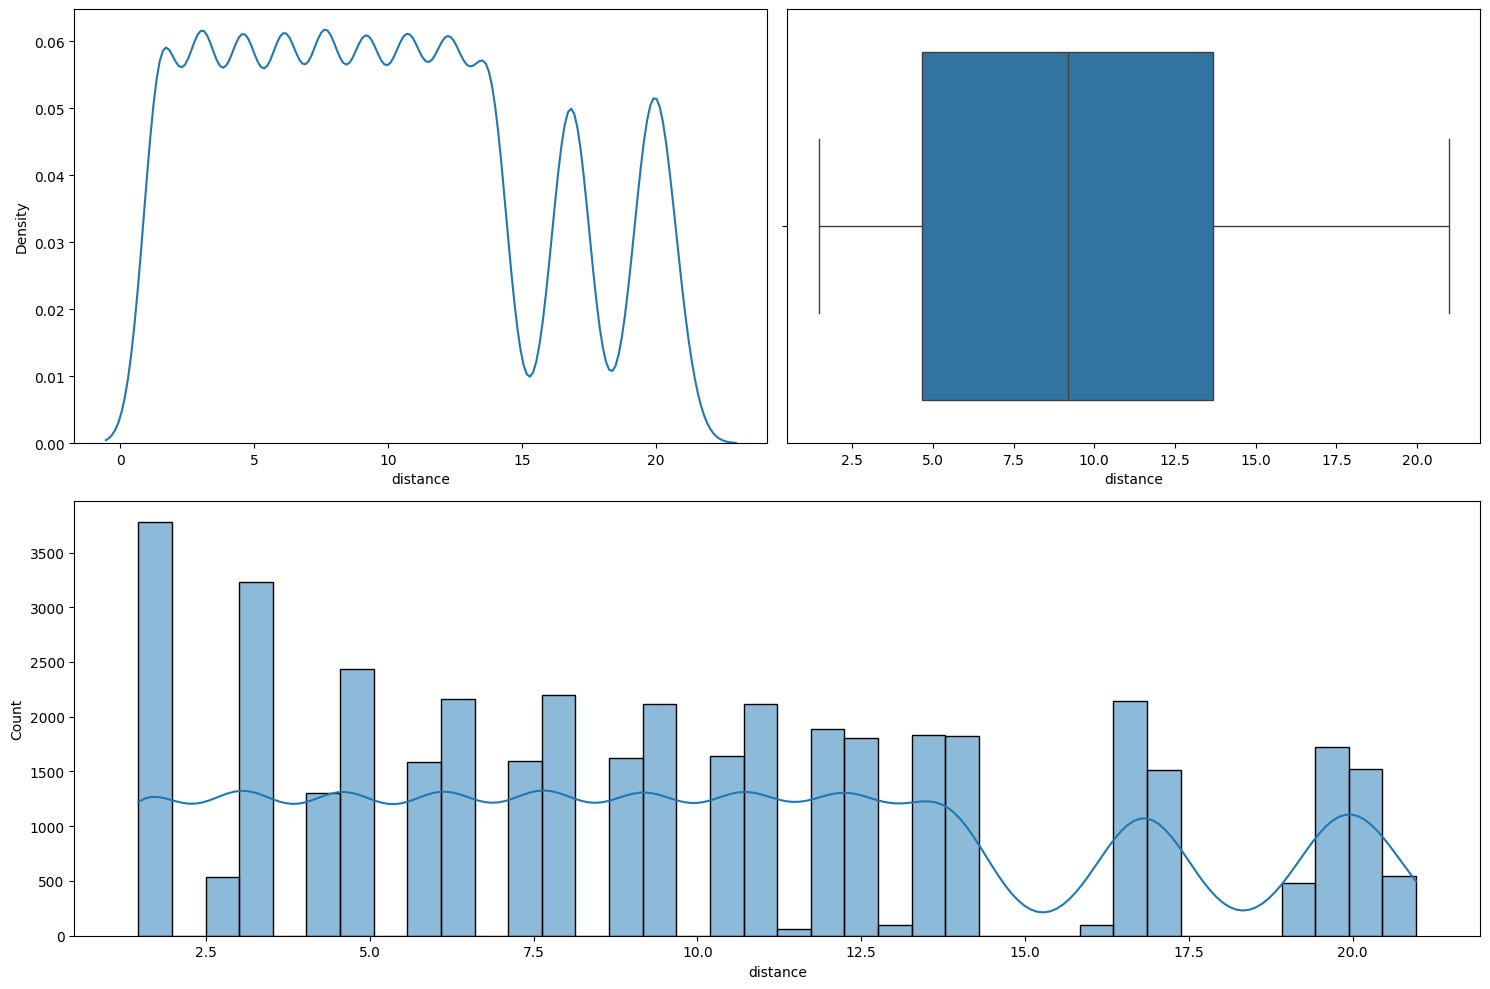

In [86]:
numerical_analysis(df_final, "distance")

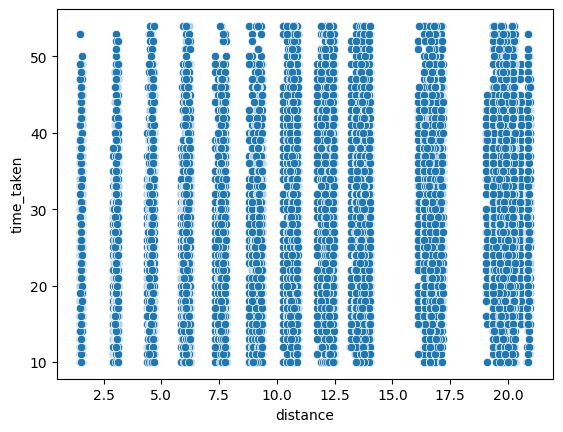

In [87]:
sns.scatterplot(df_final,x="distance",y="time_taken")
plt.show()

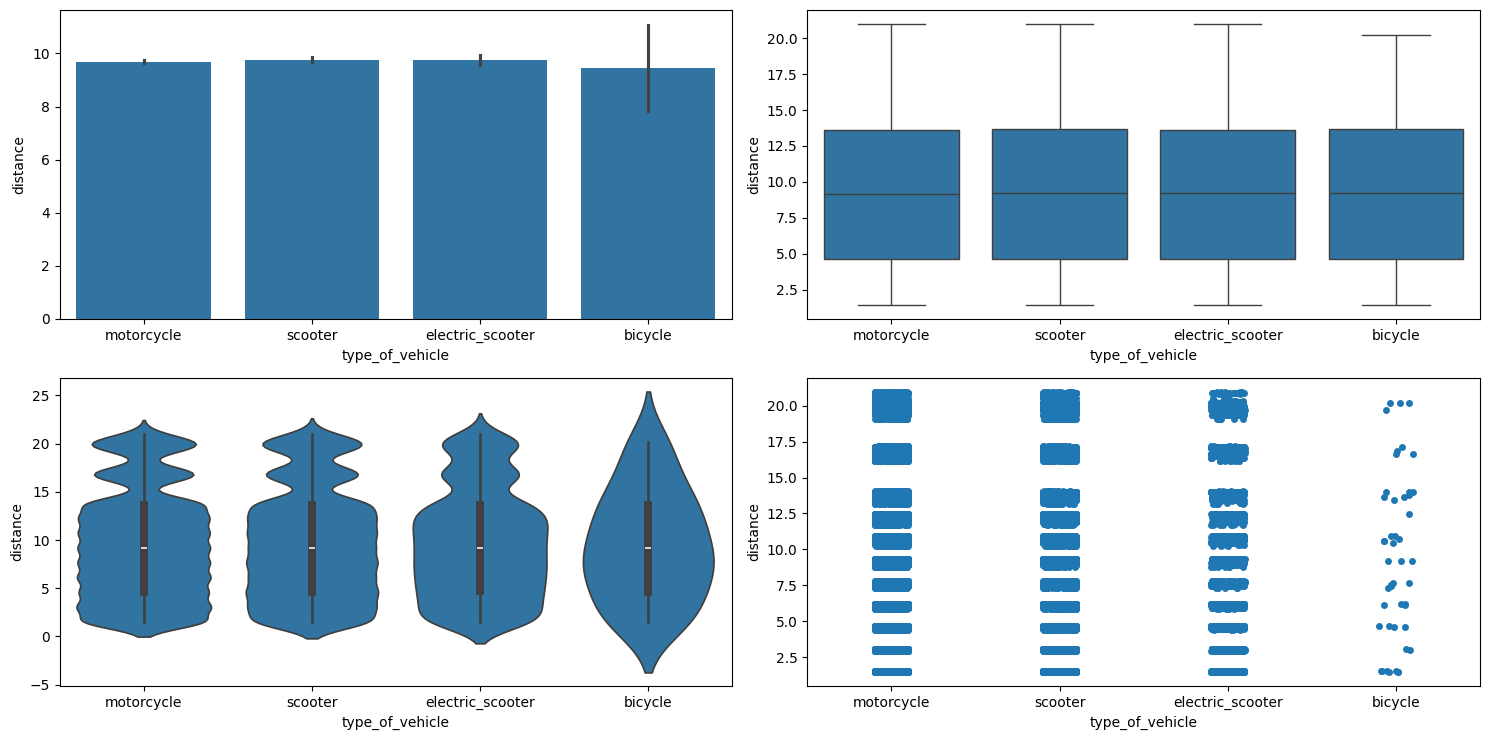

In [88]:
numerical_categorical_analysis(df_final, "type_of_vehicle", "distance")

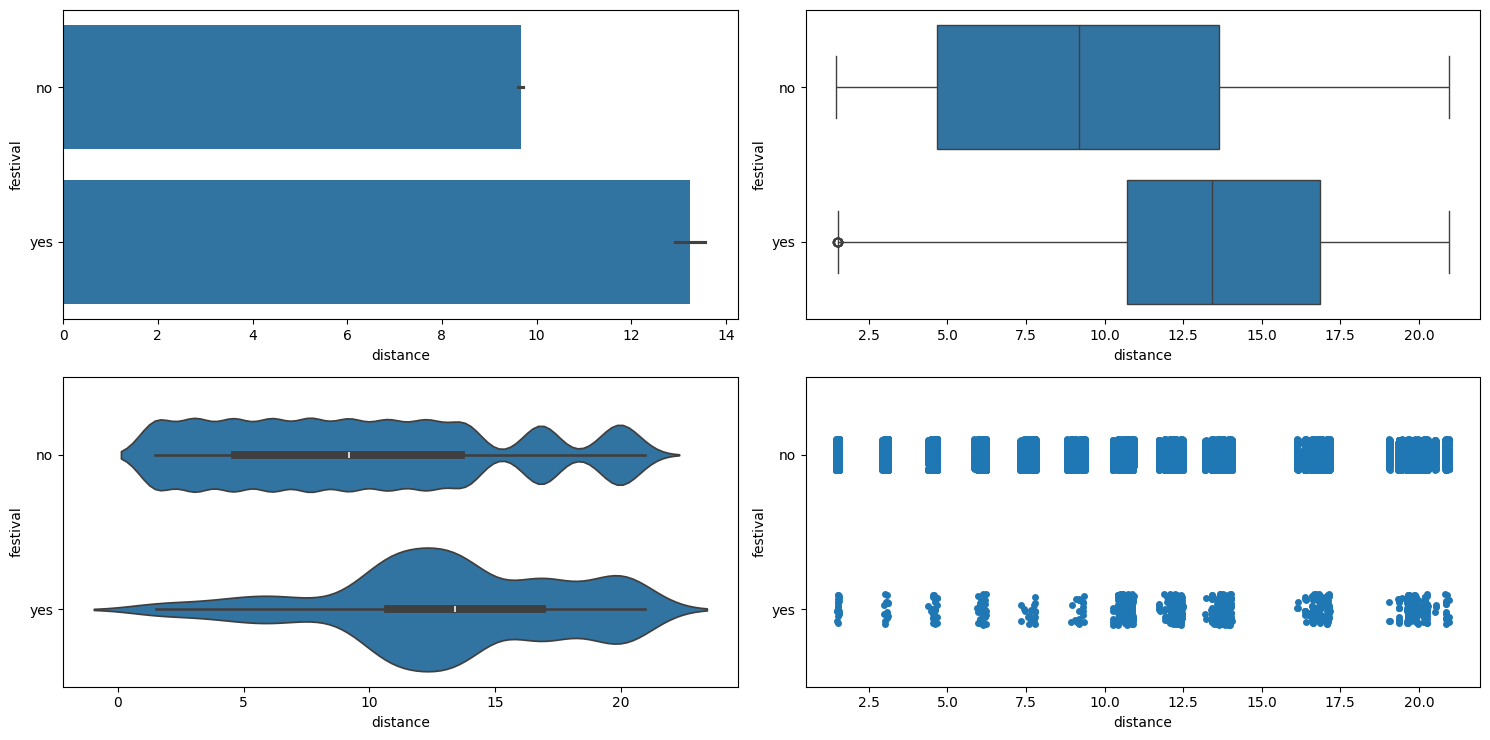

In [89]:
numerical_categorical_analysis(df_final, "distance", "festival")

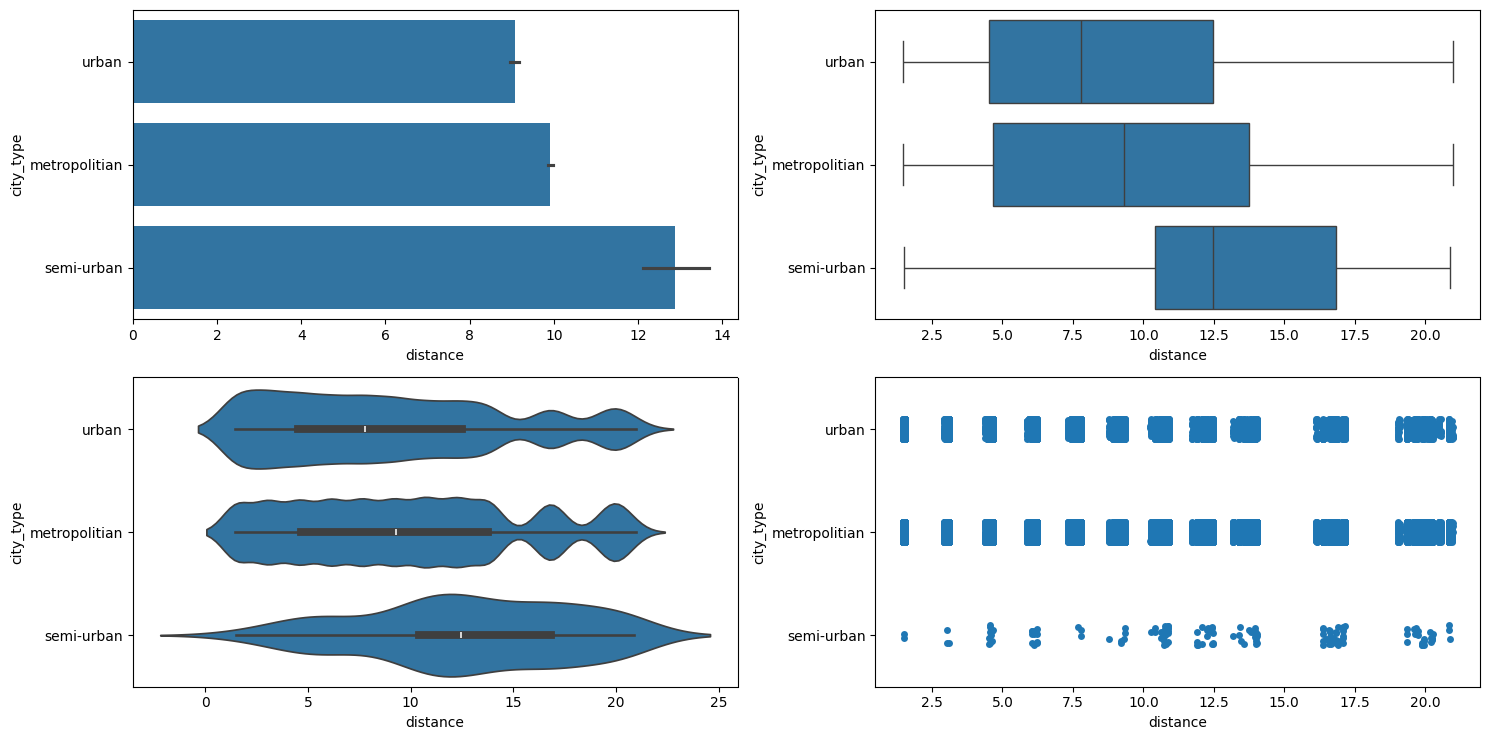

In [90]:
numerical_categorical_analysis(df_final, "distance", "city_type")

In [92]:
df_final = df_final.assign(
                        distance_type = pd.cut(df_final["distance"],bins=[0,5,10,15,25],
                                               right=False,labels=["short","medium","long","very_long"])
                                    )

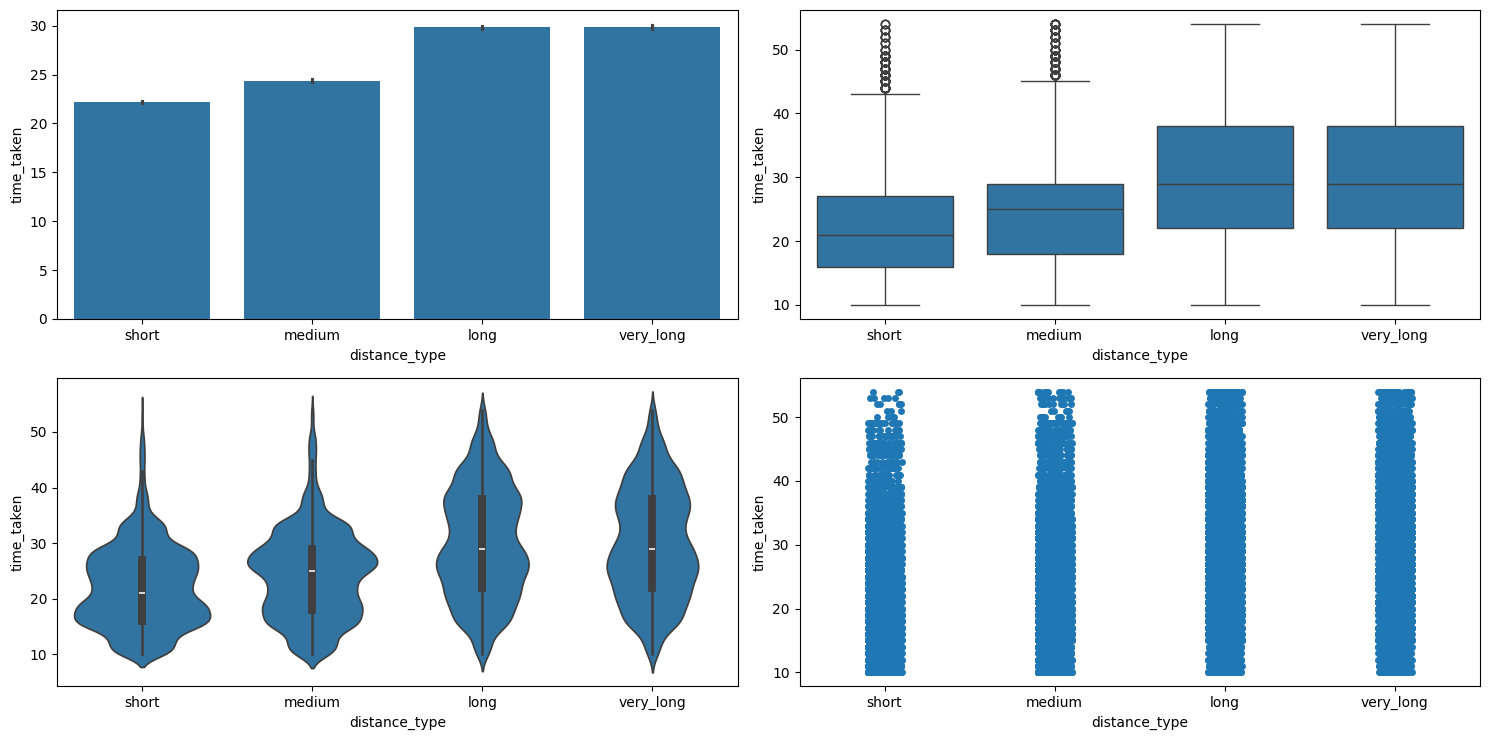

In [93]:
numerical_categorical_analysis(df_final, "distance_type", "time_taken")

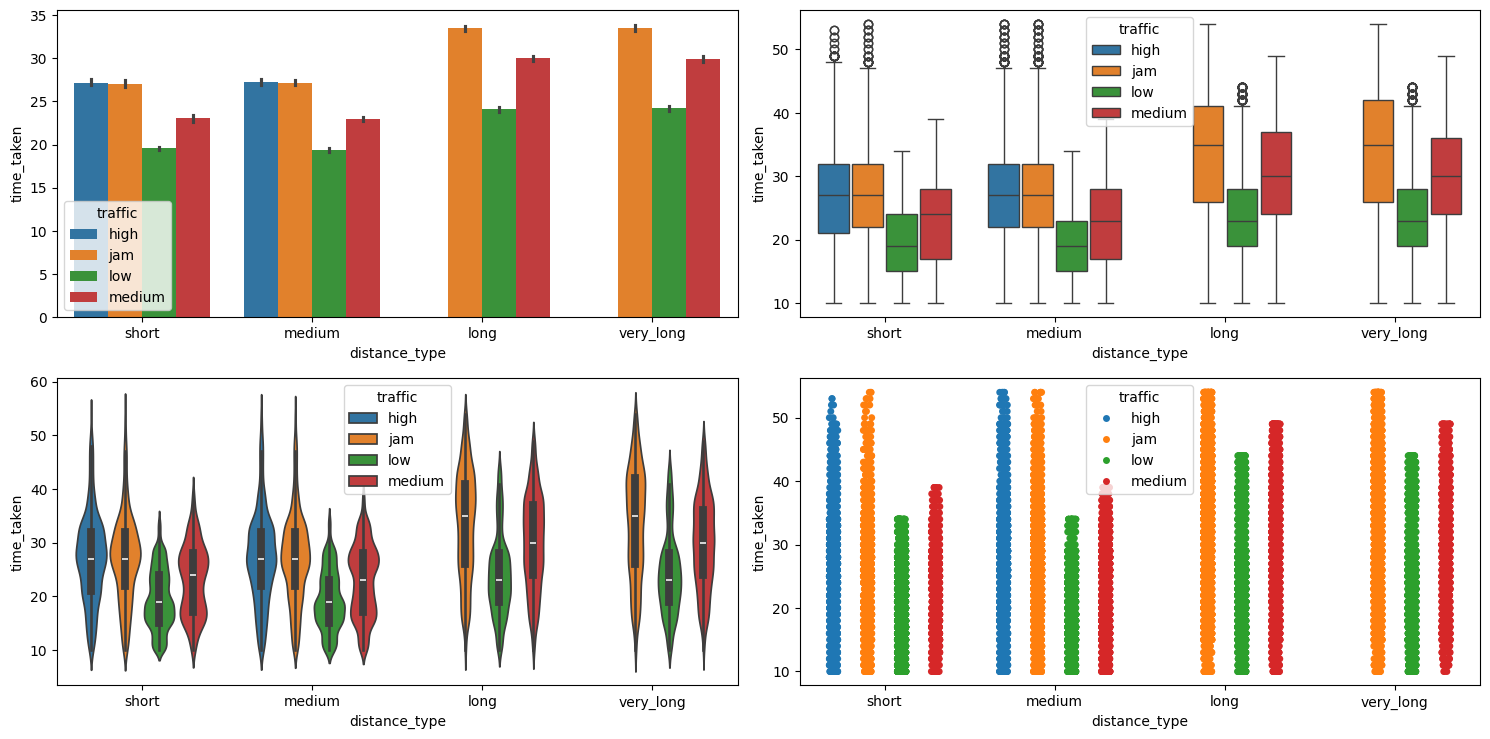

In [94]:
multivariate_analysis(df_final, "time_taken", "distance_type", "traffic")

